# Projet COMPAS : Analyse prédictive de la récidive et étude de l'équité des modèles

## Data Mining et Machine Learning

### Étudiant : FALL Pape Ahmed

### Année universitaire : 2025-2026


# Introduction

Le système COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) est un outil d'aide à la décision utilisé dans le système judiciaire américain afin d'estimer le risque de récidive d'un individu.

L'objectif de ce projet est de construire un modèle prédictif de récidive à partir des données COMPAS tout en analysant l'équité des prédictions vis-à-vis de certains groupes démographiques.

Le projet suit les étapes classiques d'un processus de Data Mining :

- exploration des données,

- nettoyage et prétraitement,

- clustering,

- modélisation prédictive,

- interprétation avec SHAP,

- analyse des biais,

- atténuation des biais,

- comparaison finale des modèles.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import umap.umap_ as umap
from sklearn.manifold import TSNE



# Exploration et compréhension des données

Avant toute prétraitement, il est nécessaire d'examiner la structure des données afin d'identifier les variables disponibles, leur type ainsi que les éventuelles valeurs manquantes, doublons etc...

**Chargement du jeu de données principal**

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/cox-violent-parsed_filt.csv")

In [ ]:
df.shape

(18316, 40)

Le jeu de données contient :

- 18 316 observations ;
- 40 variables.

La taille du dataset est suffisante pour entraîner plusieurs modèles de Machine Learning tout en conservant un ensemble de test représentatif.

**Identification des variables**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       11001 non-null  float64
 1   name                     18316 non-null  object 
 2   first                    18316 non-null  object 
 3   last                     18316 non-null  object 
 4   sex                      18316 non-null  object 
 5   dob                      18316 non-null  object 
 6   age                      18316 non-null  int64  
 7   age_cat                  18316 non-null  object 
 8   race                     18316 non-null  object 
 9   juv_fel_count            18316 non-null  int64  
 10  decile_score             18316 non-null  int64  
 11  juv_misd_count           18316 non-null  int64  
 12  juv_other_count          18316 non-null  int64  
 13  priors_count             18316 non-null  int64  
 14  days_b_screening_arres

Le dataset contient à la fois des variables numériques et catégorielles.

Les variables numériques décrivent principalement l'âge, les scores COMPAS et les antécédents judiciaires.

Les variables catégorielles correspondent notamment au sexe, à l'origine ethnique, aux catégories d'âge et aux types d'infractions.

**Analyse préliminaire des variables de récidive**

In [ ]:
df[['is_recid', 'is_violent_recid', 'event']].head(10)

,is_recid,is_violent_recid,event
0,0,0,0
1,0,0,0
2,-1,0,0
3,1,1,1
4,1,0,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,0


La présence de -1 dans is_recid indique probablement une catégorie particulière :

- information inconnue ;
- individu non éligible au suivi ;
- donnée manquante codée manuellement.
Nous ne devons pas deviner, nous allons vérifier.

**Distribution des variables de récidive**

Afin d'identifier la variable cible du projet, nous examinons la distribution des variables liées à la récidive.

In [ ]:
df['is_recid'].value_counts(dropna=False)


,count
is_recid,
0,9079
1,8417
-1,820


In [ ]:
df['is_violent_recid'].value_counts(dropna=False)


,count
is_violent_recid,
0,16977
1,1339


In [ ]:
df['event'].value_counts(dropna=False)

,count
event,
0,17497
1,819


Les variables liées à la récidive présentent les distributions suivantes :

- `is_recid` :
  - 9079 individus n'ont pas récidivé ;
  - 8417 individus ont récidivé ;
  - 820 individus possèdent la valeur -1.

- `is_violent_recid` :
  - 16977 individus n'ont pas commis de récidive violente ;
  - 1339 individus ont commis une récidive violente.

- `event` :
  - 17497 observations portent la valeur 0 ;
  - 819 observations portent la valeur 1.

La variable `is_recid` apparaît comme la variable la plus pertinente pour prédire la récidive générale. Toutefois, la présence de la valeur -1 nécessite une investigation complémentaire.

**Investigation de la variable cible**

In [ ]:
df[df['is_recid'] == -1].head()

,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
63,64.0,susan caple,susan,caple,Female,28/04/1966,49,Greater than 45,Caucasian,0,...,NaN,Risk of Recidivism,1,Low,04/03/2013,Risk of Violence,1,Low,0,0
82,83.0,matthew mchugh,matthew,mchugh,Male,14/10/1986,29,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,8,High,26/02/2013,Risk of Violence,6,Medium,0,0
111,112.0,michael wiggins,michael,wiggins,Male,25/06/1979,36,25 - 45,African-American,0,...,NaN,Risk of Recidivism,1,Low,15/04/2013,Risk of Violence,1,Low,0,0
192,193.0,sedainel allen,sedainel,allen,Male,16/04/1975,41,25 - 45,African-American,0,...,NaN,Risk of Recidivism,2,Low,14/08/2014,Risk of Violence,1,Low,0,0


In [ ]:
df[df['is_recid'] == -1][[
    'is_recid',
    'r_charge_degree',
    'r_offense_date',
    'r_charge_desc',
    'r_days_from_arrest'
]].head(20)

,is_recid,r_charge_degree,r_offense_date,r_charge_desc,r_days_from_arrest
2,-1,NaN,NaN,NaN,NaN
63,-1,NaN,NaN,NaN,NaN
82,-1,NaN,NaN,NaN,NaN
111,-1,NaN,NaN,NaN,NaN
192,-1,NaN,NaN,NaN,NaN
217,-1,NaN,NaN,NaN,NaN
226,-1,NaN,NaN,NaN,NaN
250,-1,NaN,NaN,NaN,NaN
267,-1,NaN,NaN,NaN,NaN
364,-1,NaN,NaN,NaN,NaN


*Interprétation de la valeur -1*

L'examen des individus pour lesquels `is_recid = -1` montre l'absence systématique des informations relatives à une éventuelle récidive (`r_charge_degree`, `r_offense_date`, `r_charge_desc`, `r_days_from_arrest`).

La valeur -1 ne correspond donc ni à une récidive ni à une absence de récidive. Elle représente une situation pour laquelle l'information de récidive n'est pas disponible.

Ces observations devront être exclues lors de la préparation de la variable cible.

**Analyse des valeurs manquantes**

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
violent_recid,18316
vr_offense_date,16977
vr_charge_degree,16977
vr_charge_desc,16977
r_jail_in,11957
r_days_from_arrest,11957
r_charge_desc,10039
r_charge_degree,9899
r_offense_date,9899
id,7315


In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': missing_pct
})

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
c_charge_degree,867,4.733566
c_charge_desc,881,4.810002
c_days_from_compas,867,4.733566
c_jail_in,1297,7.081240
c_jail_out,1297,7.081240
days_b_screening_arrest,1297,7.081240
id,7315,39.937759
r_charge_degree,9899,54.045643
r_charge_desc,10039,54.810002
r_days_from_arrest,11957,65.281721


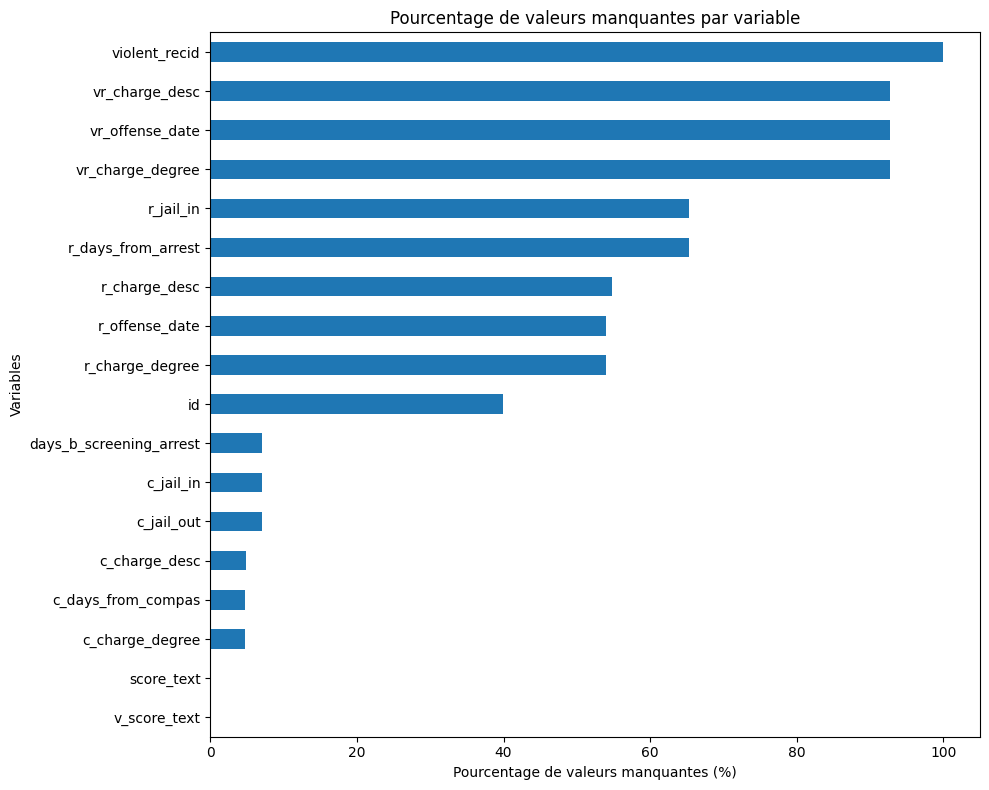

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values()

plt.figure(figsize=(10,8))
missing_pct.plot(kind='barh')
plt.xlabel('Pourcentage de valeurs manquantes (%)')
plt.ylabel('Variables')
plt.title('Pourcentage de valeurs manquantes par variable')
plt.tight_layout()
plt.show()

L'analyse des valeurs manquantes met en évidence plusieurs situations :

- La variable `violent_recid` est vide à 100 % et ne peut pas être utilisée.
- Les variables `vr_charge_degree`, `vr_charge_desc` et `vr_offense_date` contiennent plus de 92 % de valeurs manquantes.
- Les variables liées à la récidive (`r_charge_degree`, `r_charge_desc`, `r_offense_date`, `r_days_from_arrest`, `r_jail_in`) présentent plus de 50 % de valeurs manquantes. Ces absences sont principalement dues au fait qu'une grande partie des individus n'ont pas récidivé.
- Les variables `c_charge_degree`, `c_charge_desc`, `c_days_from_compas`, `c_jail_in`, `c_jail_out` et `days_b_screening_arrest` présentent moins de 10 % de valeurs manquantes.
- La variable `id` comporte près de 40 % de valeurs manquantes mais constitue uniquement un identifiant.



**Conclusion de l'analyse exploratoire**

L'analyse exploratoire montre que :

- le jeu de données présente peu de valeurs manquantes ;

- certaines variables nécessitent un encodage spécifique ;

- les variables numériques et catégorielles devront être traitées différemment ;

- les variables sensibles (race, sexe) feront l'objet d'une attention particulière dans l'analyse de l'équité.

## Prétraitement des données

Les données sont maintenant suffisamment comprises.

La prochaine étape consiste à préparer les variables afin qu'elles puissent être exploitées efficacement par les algorithmes de Machine Learning.

**Préparation de la variable cible**

In [ ]:
df_clean = df[df['is_recid'] != -1].copy()

print("Nombre de lignes avant :", len(df))
print("Nombre de lignes après :", len(df_clean))

Nombre de lignes avant : 18316
Nombre de lignes après : 17496


La variable cible retenue est `is_recid`.

Les observations pour lesquelles `is_recid = -1` ont été supprimées car elles correspondent à des situations où l'information sur la récidive n'est pas disponible.

Après ce filtrage :
- Nombre initial d'observations : 18 316
- Nombre final d'observations : 17 496

Le jeu de données obtenu contient uniquement des individus dont le statut de récidive est connu.

- **Répartition réelle de la cible**









In [ ]:
df_clean['is_recid'].value_counts()



,count
is_recid,
0,9079
1,8417


Après suppression des observations pour lesquelles le statut de récidive était inconnu (`is_recid = -1`), la variable cible présente une distribution équilibrée :

- 9079 individus (51,89 %) n'ont pas récidivé ;
- 8417 individus (48,11 %) ont récidivé.

Cette répartition est favorable à la construction de modèles de classification car elle limite les problèmes liés au déséquilibre des classes.

- **vérifiction doublons**

In [ ]:
for col in [
    'decile_score',
    'decile_score.1',
    'priors_count',
    'priors_count.1'
]:
    print("\n", col)
    print(df_clean[col].head())


 decile_score
0    1
1    1
3    3
4    4
5    4
Name: decile_score, dtype: int64

 decile_score.1
0    1
1    1
3    3
4    4
5    4
Name: decile_score.1, dtype: int64

 priors_count
0    0
1    0
3    0
4    4
5    4
Name: priors_count, dtype: int64

 priors_count.1
0    0
1    0
3    0
4    4
5    4
Name: priors_count.1, dtype: int64


In [ ]:
print((df_clean['decile_score'] == df_clean['decile_score.1']).all())
print((df_clean['priors_count'] == df_clean['priors_count.1']).all())

True
True


ces colonnes sont des doublons exacts. On peut donc déjà les supprimer.

In [ ]:
df_clean = df_clean.drop(
    columns=['decile_score.1', 'priors_count.1']
)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17496 entries, 0 to 18315
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10542 non-null  float64
 1   name                     17496 non-null  object 
 2   first                    17496 non-null  object 
 3   last                     17496 non-null  object 
 4   sex                      17496 non-null  object 
 5   dob                      17496 non-null  object 
 6   age                      17496 non-null  int64  
 7   age_cat                  17496 non-null  object 
 8   race                     17496 non-null  object 
 9   juv_fel_count            17496 non-null  int64  
 10  decile_score             17496 non-null  int64  
 11  juv_misd_count           17496 non-null  int64  
 12  juv_other_count          17496 non-null  int64  
 13  priors_count             17496 non-null  int64  
 14  days_b_screening_arrest  17

id : 10542 non-null sur 17496, un identifiant devrait être rempli partout. En plus, il n'a pas d'intérêt prédictif.

violent_recid : 0 non-null. Cette colonne est totalement vide.

Donc on peut les supprimer des colonnes.

In [ ]:
df_clean = df_clean.drop(
    columns=['id', 'violent_recid']
)

Avant de supprimer davantage de colonnes, on devrait connaître la distribution des variables cibles.

In [ ]:
print(df_clean['is_recid'].value_counts())
print(df_clean['is_violent_recid'].value_counts())
print(df_clean['event'].value_counts())

is_recid
0    9079
1    8417
Name: count, dtype: int64
is_violent_recid
0    16157
1     1339
Name: count, dtype: int64
event
0    16677
1      819
Name: count, dtype: int64


Ces résultats nous apprennent quelque chose d'important.
 - is_recid : (51.9 % non-récidive et 48.1 % récidive), pas problème de déséquilibre des classes. Donc excellent pour la modélisation.
 - is_violent_recid : (92.3 % non-récidive violente et 7.7 % récidive violente) on note beaucoup de déséquilibre.
 - event : (0 : 16677 et 1 : 819), ce n'est clairement pas un doublon de *is_recid* car (is_recid = 8417 récidivistes et event = 819 seulement).
 Donc event représente autre chose, peut être une variable liée à une analyse de survie. on verra si on va le garder ou pas après.

In [ ]:
df_clean[['event', 'is_recid', 'is_violent_recid']].head(20)


,event,is_recid,is_violent_recid
0,0,0,0
1,0,0,0
3,1,1,1
4,0,1,0
5,0,1,0
6,0,1,0
7,0,1,0
8,0,1,0
9,0,0,0
10,0,0,0


In [ ]:
pd.crosstab(df_clean['event'], df_clean['is_recid'])

is_recid,0,1
event,,
0,9079,7598
1,0,819


On constate que event = 1  ⟹  is_recid = 1 mais is_recid = 1 n'implique pas forcément event = 1. Puisqu'on a 8417 récidivistes et 819 event=1, **event ⊂ is_recid**. Ainsi vu que notre objectif est de prédire la récidive (is_recid), *even* n'est pas nécessaire comme variable explicative.

Au contraire, elle est très liée à la cible et risque d'introduire une fuite d'information.

On pourra la retirer du jeu destiné à la classification.


- **decile_score et score_text sont-elles directement calculées à partir de la cible ?**

In [ ]:
pd.crosstab(df_clean['score_text'], df_clean['is_recid'])

is_recid,0,1
score_text,,
High,1545,2921
Low,5327,2792
Medium,2197,2697


In [ ]:
pd.crosstab(df_clean['v_score_text'], df_clean['is_recid'])

is_recid,0,1
v_score_text,,
High,801,1498
Low,6410,4192
Medium,1863,2727


In [ ]:
pd.crosstab(
    df_clean['score_text'],
    df_clean['is_recid'],
    normalize='index'
) * 100

is_recid,0,1
score_text,,
High,34.594716,65.405284
Low,65.611529,34.388471
Medium,44.891704,55.108296


In [ ]:
pd.crosstab(
    df_clean['v_score_text'],
    df_clean['is_recid'],
    normalize='index'
) * 100

is_recid,0,1
v_score_text,,
High,34.841235,65.158765
Low,60.460291,39.539709
Medium,40.588235,59.411765


L'analyse montre une relation claire entre les scores COMPAS et la récidive observée. Le taux de récidive augmente avec le niveau de risque attribué par l'algorithme, aussi bien pour score_text que pour v_score_text. Les individus classés High récidivent davantage que ceux classés Low, ce qui suggère que ces scores sont informatifs pour prédire la récidive. Toutefois, cette relation n'est pas parfaite, certains individus à faible risque récidivant malgré tout. Les variables de score COMPAS seront donc conservées pour les analyses futures.

**Typologie des variables**

Avant d'entreprendre les analyses multivariées et la préparation des données, il est nécessaire d'identifier la nature de chaque variable. Cette étape permettra de choisir les méthodes statistiques appropriées et d'adapter les traitements ultérieurs (gestion des valeurs manquantes, encodage, ACP, etc.).

In [ ]:
df_clean.dtypes.sort_values()

,0
event,int64
is_recid,int64
is_violent_recid,int64
priors_count,int64
juv_other_count,int64
decile_score,int64
juv_fel_count,int64
juv_misd_count,int64
age,int64
v_decile_score,int64


 - *1 - Variables cibles*

| Variable         | Description                        |
| ---------------- | ---------------------------------- |
| is_recid         | récidive observée                  |
| is_violent_recid | récidive violente observée         |
| event            | indicateur d'événement de récidive |


- *2. Variables numériques*

In [ ]:
num_cols = [
    'age',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'decile_score',
    'v_decile_score',
    'days_b_screening_arrest',
    'c_days_from_compas',
    'r_days_from_arrest'
]

Ces variables représentent :

l'âge, le nombre d'antécédents judiciaires,
les scores COMPAS, des délais exprimés en jours.

Elles pourront être étudiées par : statistiques descriptives;histogrammes; boxplots;
corrélations.

- *3. Variables catégorielles*

In [ ]:
cat_cols = [
    'sex',
    'race',
    'age_cat',
    'c_charge_degree',
    'c_charge_desc',
    'r_charge_degree',
    'r_charge_desc',
    'vr_charge_degree',
    'vr_charge_desc',
    'score_text',
    'v_score_text',
    'type_of_assessment',
    'v_type_of_assessment'
]

**Remarque importante**
On mettrais pas encore : **name**, **firstet** **last** dans les variables explicatives.
En effet, ce sont des identifiants individuels.
Elles n'apportent pas d'information criminologique exploitable.

Elles pourront être supprimer plus tard. Mais  il faut le justifier.

- *4. Variables temporelles*

In [ ]:
date_cols = [
    'dob',
    'screening_date',
    'c_jail_in',
    'c_jail_out',
    'r_offense_date',
    'r_jail_in',
    'vr_offense_date'
]

Ces variables décrivent : la date de naissance, les dates d'incarcération, les dates d'infraction, les dates d'évaluation COMPAS.

Elles sont actuellement stockées au format texte (object) et devront être converties au format datetime avant toute exploitation.

- *statistiques descriptives*

Avant d'étudier les distributions, il faut savoir quelles variables sont réellement exploitables.

In [ ]:
missing_pct = (
    df_clean.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct.to_frame("Pourcentage de NA")

,Pourcentage de NA
vr_charge_desc,92.346822
vr_charge_degree,92.346822
vr_offense_date,92.346822
r_days_from_arrest,63.654550
r_jail_in,63.654550
r_charge_desc,52.692044
r_charge_degree,51.891861
r_offense_date,51.891861
c_jail_in,2.732053
c_jail_out,2.732053


Les variables présentent des niveaux très différents de données manquantes.
- Grp1 : très fort taux de valeurs manquantes (> 50 %)
- Grp2 : faible taux de valeurs manquantes (< 5 %)
- Grp3 : aucune valeur manquante

In [ ]:
leakage_cols = [
    'r_charge_degree',
    'r_days_from_arrest',
    'r_offense_date',
    'r_charge_desc',
    'r_jail_in',
    'vr_charge_degree',
    'vr_offense_date',
    'vr_charge_desc'
]

df_clean[leakage_cols].notna().mean()*100

,0
r_charge_degree,48.108139
r_days_from_arrest,36.345450
r_offense_date,48.108139
r_charge_desc,47.307956
r_jail_in,36.345450
vr_charge_degree,7.653178
vr_offense_date,7.653178
vr_charge_desc,7.653178


Les variables présentent des proportions très différentes de valeurs manquantes.

Les variables vr_charge_desc, vr_charge_degree et vr_offense_date possèdent plus de 92 % de valeurs manquantes. Cette situation n'est toutefois pas due à un problème de collecte de données. Ces variables décrivent des informations relatives à une éventuelle récidive violente et ne sont renseignées que pour les individus ayant effectivement récidivé de manière violente.

De manière similaire, les variables r_charge_desc, r_charge_degree, r_offense_date, r_days_from_arrest et r_jail_in présentent entre 52 % et 64 % de valeurs manquantes. Ces variables correspondent à des informations observées après une éventuelle récidive et ne sont donc disponibles que pour une partie des individus.

Une vérification du pourcentage de valeurs non manquantes montre que les variables r_* sont renseignées pour environ 36 % à 48 % des observations, tandis que les variables vr_* ne le sont que pour environ 7.6 % des individus.

Ces variables contiennent des informations observées après l'événement de récidive et pourraient donc introduire une fuite d'information (data leakage) lors de la construction d'un modèle prédictif. Elles devront être examinées avec attention avant l'étape de modélisation.

### Analyse des variables catégorielles principales

on fait cette analyse parce que le sujet COMPAS tourne autour de la récidive et des biais potentiels selon les groupes démographiques. Les variables race, sex et age_cat sont donc centrales dans l'analyse exploratoire et seront probablement réutilisées plus tard pour discuter de l'équité du modèle.

- **Race**

In [ ]:
df_clean['race'].value_counts()
df_clean['race'].value_counts(normalize=True)*100

,proportion
race,
African-American,53.835162
Caucasian,33.047554
Hispanic,7.744627
Other,4.715364
Asian,0.365798
Native American,0.291495


La population étudiée est majoritairement composée d'individus identifiés comme African-American (53.8 %), suivis des Caucasian (33.0 %).

Les groupes Hispanic (7.7 %) et Other (4.7 %) sont nettement moins représentés, tandis que les catégories Asian et Native American représentent chacune moins de 1 % des observations.

Cette distribution met en évidence un déséquilibre entre les groupes raciaux présents dans le jeu de données. Plus de la moitié des individus appartiennent à la catégorie African-American, alors que certaines catégories sont très faiblement représentées.

Cette information est importante pour plusieurs raisons :
 - Représentativité des groupes : Les résultats obtenus sur les groupes très minoritaires (Asian, Native American) devront être interprétés avec prudence en raison de leur faible effectif.
 - Analyse de la récidive : L'un des objectifs du projet est d'étudier les facteurs associés à la récidive.
 - Analyse d'équité : Le jeu de données COMPAS est connu pour avoir suscité des débats concernant l'équité des scores de risque entre différents groupes raciaux.
 La variable race jouera donc un rôle central dans l'évaluation de l'éventuelle présence de biais lors des analyses ultérieures.

- *Analyse de la récidive*

In [ ]:
pd.crosstab(
    df_clean['race'],
    df_clean['is_recid'],
    normalize='index'
) * 100

is_recid,0,1
race,,
African-American,46.055845,53.944155
Asian,70.312500,29.687500
Caucasian,57.212037,42.787963
Hispanic,63.468635,36.531365
Native American,50.980392,49.019608
Other,60.848485,39.151515


Les taux de récidive observés diffèrent selon les groupes raciaux.

Les individus classés comme African-American présentent le taux de récidive le plus élevé parmi les groupes les plus représentés du jeu de données, avec environ 54 % de récidive contre 46 % de non-récidive.

À l'inverse, les individus classés comme Caucasian présentent un taux de récidive inférieur (42.8 %), tandis que les groupes Hispanic et Other affichent des taux encore plus faibles, respectivement 36.5 % et 39.2 %.

Les catégories Asian et Native American doivent être interprétées avec prudence en raison de leur très faible effectif dans le jeu de données. Les pourcentages observés pour ces groupes peuvent être fortement influencés par quelques observations seulement.

Cette analyse suggère l'existence d'une association entre la variable race et la variable cible is_recid.

Toutefois, ces résultats sont purement descriptifs et ne permettent pas d'établir une relation causale. Les différences observées peuvent également être influencées par d'autres facteurs présents dans le jeu de données tels que l'âge, les antécédents judiciaires (priors_count) ou les scores COMPAS.

Une analyse statistique plus approfondie sera nécessaire pour déterminer si cette association reste significative lorsque plusieurs variables sont considérées simultanément.

- *Test du Chi²*

Ce test permet de vérifier si la variable race et la variable is_recid sont indépendantes.

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_clean['race'], df_clean['is_recid'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2 :", chi2)
print("p-value :", p)

Chi2 : 302.0318154538011
p-value : 3.6629330662119384e-63


On a **p-value est < 0.05**, le résultat indique qu'il existe une association statistiquement significative entre la race et la récidive dans le jeu de données étudié.

Cette conclusion est cohérente avec les différences observées précédemment dans les taux de récidive selon les groupes raciaux.

Cependant, cette association ne doit pas être interprétée comme une relation de causalité. D'autres variables, telles que l'âge, le nombre d'antécédents judiciaires (priors_count) ou les scores COMPAS, peuvent également influencer les taux de récidive observés.

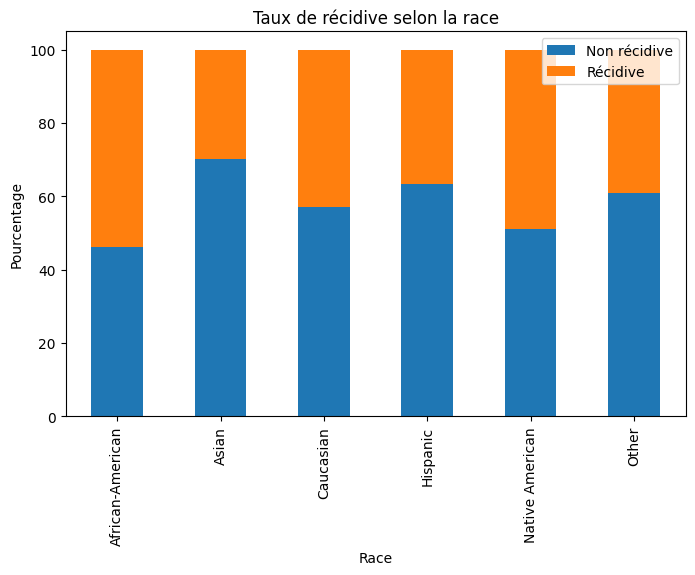

In [ ]:
race_recid = pd.crosstab(
    df_clean['race'],
    df_clean['is_recid'],
    normalize='index'
) * 100

race_recid.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Taux de récidive selon la race")
plt.ylabel("Pourcentage")
plt.xlabel("Race")
plt.legend(["Non récidive", "Récidive"])
plt.show()

- **Sex**

In [ ]:
df_clean['sex'].value_counts(normalize=True) * 100

,proportion
sex,
Male,81.601509
Female,18.398491


La population étudiée est très majoritairement composée d'hommes, qui représentent environ 81,6 % des individus du jeu de données, contre 18,4 % de femmes.

Cette répartition révèle un déséquilibre important entre les deux catégories de sexe. En pratique, cela signifie que les analyses statistiques réalisées sur les hommes reposeront sur un effectif beaucoup plus important que celles concernant les femmes.

- *Étude de la récidive selon le sexe*

In [ ]:
pd.crosstab(
    df_clean['sex'],
    df_clean['is_recid'],
    normalize='index'
) * 100

is_recid,0,1
sex,,
Female,61.882572,38.117428
Male,49.639280,50.360720


Les taux de récidive diffèrent selon le sexe.

Les femmes présentent une proportion de récidive d'environ 38 %, tandis que près de 62 % d'entre elles ne récidivent pas.

À l'inverse, chez les hommes, la proportion de récidive atteint environ 50 %, ce qui correspond à une répartition presque équilibrée entre récidivistes et non-récidivistes.

Ainsi, dans ce jeu de données, les hommes apparaissent plus susceptibles de récidiver que les femmes.

- Test du Chi²

In [ ]:
table = pd.crosstab(df_clean['sex'], df_clean['is_recid'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2 :", chi2)
print("p-value :", p)

Chi2 : 157.23395257772773
p-value : 4.550178317381362e-36


Comme pour la race nous rejetons l'hypothèse nulle d'indépendance.

Le sexe semble donc constituer une variable pertinente dans l'étude de la récidive au sein de ce jeu de données.

Toutefois, comme précédemment, cette association ne doit pas être interprétée comme une relation causale. D'autres facteurs peuvent contribuer aux différences observées.

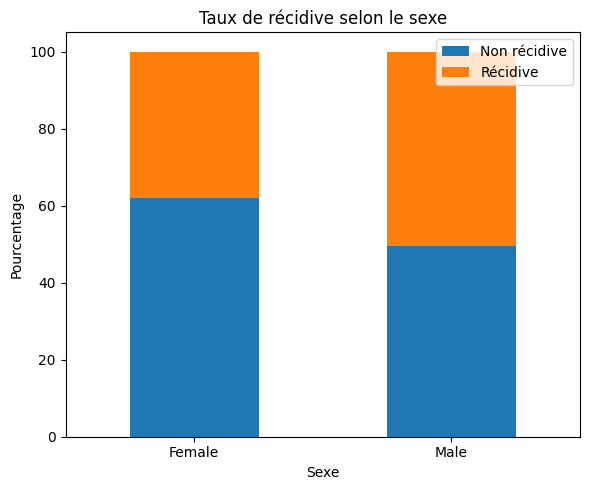

In [ ]:
sex_recid = pd.crosstab(
    df_clean['sex'],
    df_clean['is_recid'],
    normalize='index'
) * 100

ax = sex_recid.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5)
)

plt.title("Taux de récidive selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Pourcentage")
plt.legend(["Non récidive", "Récidive"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

-  **Age_cat**

In [ ]:
df_clean['age_cat'].value_counts(normalize=True) * 100

,proportion
age_cat,
25 - 45,56.950160
Less than 25,23.319616
Greater than 45,19.730224


In [ ]:
pd.crosstab(
    df_clean['age_cat'],
    df_clean['is_recid'],
    normalize='index'
)*100

is_recid,0,1
age_cat,,
25 - 45,51.545564,48.454436
Greater than 45,63.702202,36.297798
Less than 25,42.745098,57.254902


Les taux de récidive varient fortement selon la catégorie d'âge.

Les individus âgés de moins de 25 ans présentent le taux de récidive le plus élevé, avec environ 57 % de récidivistes.

Le groupe intermédiaire (25 à 45 ans) présente un taux de récidive proche de l'équilibre, avec environ 48 % de récidivistes.

À l'inverse, les individus de plus de 45 ans présentent le taux de récidive le plus faible, avec seulement 36 % de récidivistes.

- *Test du Chi²*

In [ ]:
table = pd.crosstab(df_clean['age_cat'], df_clean['is_recid'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2 :", chi2)
print("p-value :", p)

Chi2 : 330.0887019496647
p-value : 2.0996606170470024e-72


L'hypothèse nulle d'indépendance est rejetée.

Parmi les variables démographiques étudiées jusqu'à présent, l'âge apparaît comme l'un des facteurs les plus fortement liés à la récidive.

Les individus les plus jeunes présentent les taux de récidive les plus élevés, tandis que les individus les plus âgés présentent les taux les plus faibles.

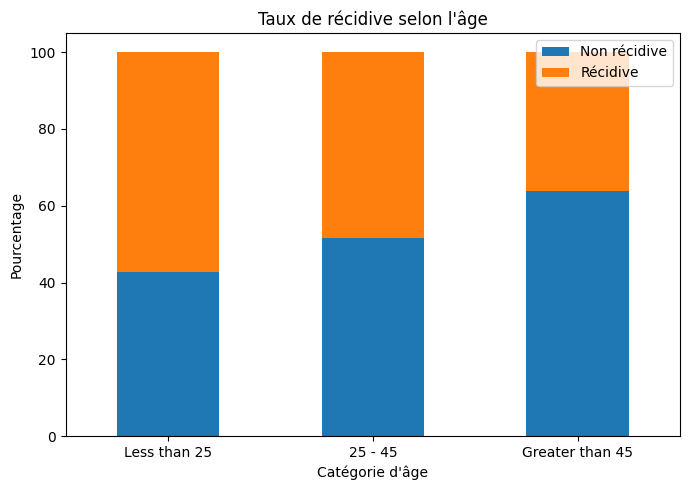

In [ ]:
age_recid = pd.crosstab(
    df_clean['age_cat'],
    df_clean['is_recid'],
    normalize='index'
)*100

ordre = ['Less than 25', '25 - 45', 'Greater than 45']
age_recid = age_recid.reindex(ordre)

ax = age_recid.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Taux de récidive selon l'âge")
plt.xlabel("Catégorie d'âge")
plt.ylabel("Pourcentage")
plt.legend(["Non récidive", "Récidive"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

L'analyse des variables démographiques montre que la récidive varie significativement selon la race, le sexe et l'âge.

Les tests du Chi² réalisés indiquent que chacune de ces variables est statistiquement associée à la récidive :

| Variable |   Chi² |      p-value |
| -------- | -----: | -----------: |
| Race     | 302.03 | 3.66 × 10⁻⁶³ |
| Sex      | 157.23 | 4.55 × 10⁻³⁶ |
| Age_cat  | 330.09 | 2.10 × 10⁻⁷² |

Ces résultats suggèrent que les caractéristiques démographiques constituent des facteurs potentiellement pertinents pour l'étude et la prédiction de la récidive.

**regroupement des futures par thématique**

In [ ]:
target = ['is_recid']

demo_cols = [
    'race',
    'sex',
    'age',
    'age_cat'
]

history_cols = [
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'is_violent_recid'
]

compas_cols = [
    'decile_score',
    'score_text',
    'v_decile_score',
    'v_score_text'
]

justice_cols = [
    'c_charge_degree',
    'c_charge_desc',
    'r_charge_degree',
    'r_charge_desc',
    'vr_charge_degree',
    'vr_charge_desc'
]

time_cols = [
    'days_b_screening_arrest',
    'c_days_from_compas',
    'r_days_from_arrest'
]

**Cardinalités**

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()}")

name: 10855
first: 3876
last: 5635
sex: 2
dob: 7485
age_cat: 3
race: 6
c_jail_in: 9806
c_jail_out: 8714
c_charge_degree: 14
c_charge_desc: 513
r_charge_degree: 10
r_offense_date: 1075
r_charge_desc: 341
r_jail_in: 972
vr_charge_degree: 9
vr_offense_date: 570
vr_charge_desc: 83
type_of_assessment: 1
score_text: 3
screening_date: 703
v_type_of_assessment: 1
v_score_text: 3


Les variables suivantes ne décrivent pas le comportement criminel mais l'identité des individus. On va donc les supprimer.

In [ ]:
cols_to_drop = [
    'name',
    'first',
    'last',
    'dob'
]

df_clean = df_clean.drop(columns=cols_to_drop)

**Sauvegarde EDA**

In [ ]:
import pickle

with open("df_after_eda.pkl", "wb") as f:
    pickle.dump(df, f)

## Préparation des données

**Définir X et y**

In [ ]:
y = df_clean['is_recid']
X = df_clean.drop(columns=['is_recid', 'event'])

In [ ]:
X.dtypes.value_counts()

,count
object,19
int64,8
float64,3


**Relations entre les variables numériques**

In [ ]:
corr = df[num_cols].corr()
corr.round(2)



,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,decile_score,v_decile_score,days_b_screening_arrest,c_days_from_compas,r_days_from_arrest
age,1.00,-0.06,-0.11,-0.16,0.18,-0.36,-0.56,-0.03,0.09,0.01
juv_fel_count,-0.06,1.00,0.09,0.07,0.17,0.19,0.19,0.02,0.00,-0.02
juv_misd_count,-0.11,0.09,1.00,0.29,0.22,0.19,0.18,0.01,0.02,0.01
juv_other_count,-0.16,0.07,0.29,1.00,0.10,0.19,0.21,0.00,-0.01,-0.00
priors_count,0.18,0.17,0.22,0.10,1.00,0.41,0.19,0.00,0.01,-0.04
decile_score,-0.36,0.19,0.19,0.19,0.41,1.00,0.76,0.04,0.04,-0.04
v_decile_score,-0.56,0.19,0.18,0.21,0.19,0.76,1.00,0.05,-0.02,-0.03
days_b_screening_arrest,-0.03,0.02,0.01,0.00,0.00,0.04,0.05,1.00,0.09,0.05
c_days_from_compas,0.09,0.00,0.02,-0.01,0.01,0.04,-0.02,0.09,1.00,0.01
r_days_from_arrest,0.01,-0.02,0.01,-0.00,-0.04,-0.04,-0.03,0.05,0.01,1.00


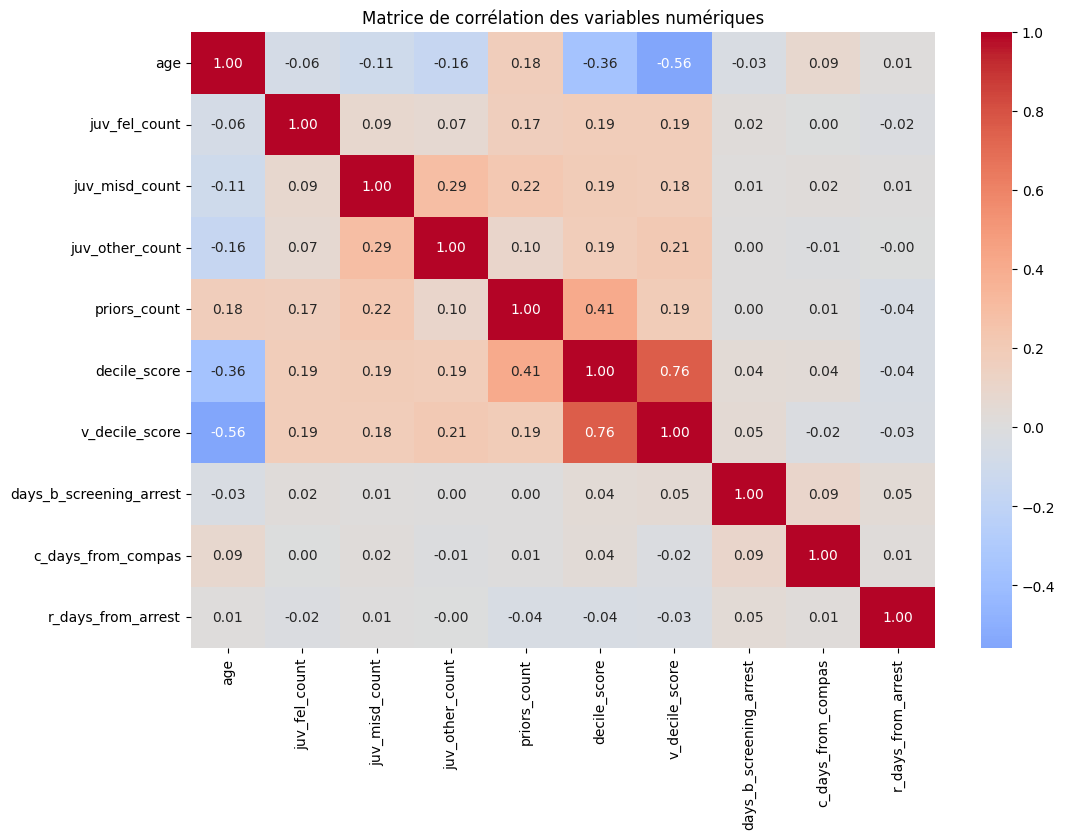

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

L'analyse de corrélation montre que les scores COMPAS sont principalement associés à l'âge et au nombre d'antécédents judiciaires. Le score général (decile_score) est positivement corrélé au nombre d'antécédents (priors_count, r=0.41) et négativement corrélé à l'âge (r=-0.36). Le score de violence (v_decile_score) présente une relation encore plus forte avec l'âge (r=-0.56). Les variables relatives aux infractions juvéniles montrent seulement des corrélations faibles (≈0.19 à 0.22), tandis que les variables temporelles liées aux dates d'arrestation ou d'évaluation présentent des corrélations quasi nulles.

**Prétraitement des variables pour la modélisation**

- *suppression des variables très incomplètes*

Les variables présentant plus de 50 % de valeurs manquantes ont été retirées afin de préserver la qualité des données et d'éviter une imputation excessive.

In [ ]:
cols_to_drop = [
    'vr_charge_desc',
    'vr_charge_degree',
    'vr_offense_date',
    'r_days_from_arrest',
    'r_jail_in',
    'r_charge_desc',
    'r_charge_degree',
    'r_offense_date'
]

X = X.drop(columns=cols_to_drop)

In [ ]:
X.shape

(17496, 22)

In [ ]:
X.isna().mean().sort_values(ascending=False).head(15)

,0
c_jail_in,0.027321
days_b_screening_arrest,0.027321
c_jail_out,0.027321
c_charge_desc,0.003544
c_days_from_compas,0.002743
c_charge_degree,0.002743
score_text,0.000972
v_score_text,0.000286
decile_score,0.000000
juv_fel_count,0.000000


Cette sortie montre des valeurs manquantes reestantes très faible. Donc on a pas à supprimer plusde colonnes, une simple imputation suffira.

In [ ]:
X.columns.tolist()

['sex',
 'age',
 'age_cat',
 'race',
 'juv_fel_count',
 'decile_score',
 'juv_misd_count',
 'juv_other_count',
 'priors_count',
 'days_b_screening_arrest',
 'c_jail_in',
 'c_jail_out',
 'c_days_from_compas',
 'c_charge_degree',
 'c_charge_desc',
 'is_violent_recid',
 'type_of_assessment',
 'score_text',
 'screening_date',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text']

On constate que **x.colums** contien **'is_violent_recid'** or notre cible est **y = is_recid**. Le problème est que :
- is_violent_recid indique déjà si la personne a récidivé violemment ;
- c'est une information qui survient après ou en même temps que la récidive ;
- elle risque de constituer une fuite d'information (target leakage).

Pour un projet prédictif COMPAS, on peut fortement de la retirer.

In [ ]:
X = X.drop(columns=['is_violent_recid'])

On contate aussi que les colonnes de date sont des chaînes de caractères.
Un modèle sklearn ne pourra pas les utiliser directement.

On prefere les retirer. En effet, elles ne sont pas directement exploitables par les modèles de classification et aucune variable temporelle dérivée n'a été retenue dans cette étude. Elles risquent d'introduire du bruit plus que du signal.

In [ ]:
date_cols_to_drop = [
    'c_jail_in',
    'c_jail_out',
    'screening_date'
]

X = X.drop(columns=date_cols_to_drop)

- *Variables numériques et catégorielles*

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Variables numériques :", len(num_cols))
print(num_cols)

print("\nVariables catégorielles :", len(cat_cols))
print(cat_cols)

Variables numériques : 9
['age', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_days_from_compas', 'v_decile_score']

Variables catégorielles : 9
['sex', 'age_cat', 'race', 'c_charge_degree', 'c_charge_desc', 'type_of_assessment', 'score_text', 'v_type_of_assessment', 'v_score_text']


**Analyse en Composantes Principales (ACP)**

Avant ACP, on a constaté que deux variables numériques présentaient un faible taux de valeurs manquantes : days_b_screening_arrest (2,73 %) et c_days_from_compas (0,27 %). Afin de conserver l'ensemble des observations disponibles pour l'analyse en composantes principales (ACP), les valeurs manquantes ont été remplacées par la médiane de chaque variable. Cette méthode est robuste aux valeurs extrêmes et adaptée aux variables temporelles présentes dans le jeu de données.

In [ ]:
X_num = X.select_dtypes(include=['int64', 'float64'])

imputer = SimpleImputer(strategy='median')

X_num_imputed = imputer.fit_transform(X_num)

In [ ]:
np.isnan(X_num_imputed).sum()

np.int64(0)

In [ ]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_imputed)

pca = PCA()

X_pca = pca.fit_transform(X_num_scaled)
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.27501223 0.14561359 0.12114897 0.11751793 0.10254924 0.0981741
 0.07749432 0.04096747 0.02152215]


In [ ]:
cum_var = np.cumsum(explained_variance)

for i, v in enumerate(cum_var, start=1):
    print(f"PC{i}: {v:.4f}")

PC1: 0.2750
PC2: 0.4206
PC3: 0.5418
PC4: 0.6593
PC5: 0.7618
PC6: 0.8600
PC7: 0.9375
PC8: 0.9785
PC9: 1.0000


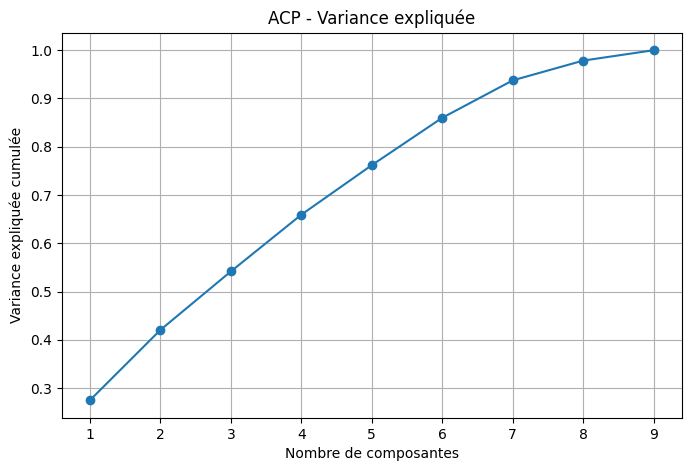

In [ ]:
explained_variance = pca.explained_variance_ratio_

cum_var = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("ACP - Variance expliquée")
plt.grid()

plt.show()

Une ACP a été réalisée sur les 9 variables quantitatives après standardisation. Les six premières composantes principales expliquent environ 86 % de la variance totale du jeu de données, tandis que les sept premières en expliquent près de 94 %. Cette concentration de l'information dans un nombre réduit d'axes confirme l'existence de redondances entre certaines variables quantitatives, notamment les scores COMPAS et certaines variables liées aux antécédents judiciaires.

 On va garder 6 composantes, car :
- on réduit de 9 variables numériques à 6 composantes ;
- on conserve déjà 86 % de l'information ;

- *comprendre les composantes*

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(num_cols))],
    index=num_cols
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
age,-0.367,0.595,0.020,-0.067,0.021,-0.095,-0.173,0.669,0.141
juv_fel_count,0.214,0.218,0.155,-0.263,0.417,0.799,0.030,0.006,-0.027
decile_score,0.545,0.047,0.195,-0.169,-0.167,-0.187,-0.081,0.334,-0.673
juv_misd_count,0.271,0.294,-0.415,0.392,0.056,-0.001,0.704,0.123,-0.016
juv_other_count,0.269,0.071,-0.488,0.450,0.081,0.135,-0.676,-0.011,-0.013
priors_count,0.261,0.645,0.053,-0.252,-0.016,-0.318,-0.096,-0.560,0.161
days_b_screening_arrest,0.048,-0.006,0.525,0.478,0.640,-0.289,-0.024,-0.002,-0.007
c_days_from_compas,-0.009,0.209,0.478,0.489,-0.606,0.332,-0.007,-0.099,0.032
v_decile_score,0.553,-0.214,0.140,-0.101,-0.107,-0.072,-0.017,0.319,0.707


L'ACP réalisée sur les neuf variables quantitatives montre que les six premières composantes principales expliquent environ 86 % de la variance totale. La première composante (27,5 %) est principalement associée aux scores COMPAS, aux antécédents judiciaires et à l'âge. Elle peut être interprétée comme un axe de risque de récidive. La deuxième composante (14,6 %) est dominée par l'âge et le nombre d'antécédents, reflétant davantage l'expérience judiciaire accumulée. La troisième composante (12,1 %) est principalement liée aux variables temporelles associées aux procédures judiciaires.

Cette analyse met en évidence trois grandes familles de variables quantitatives : les scores de risque COMPAS, les antécédents judiciaires et les variables temporelles. Elle confirme également l'existence d'une forte redondance entre certaines variables, notamment entre les scores COMPAS général et violent.


**ACM**

In [ ]:
for col in cat_cols:
    print(f"{col}: {df_clean[col].nunique()}")

sex: 2
age_cat: 3
race: 6
c_charge_degree: 14
c_charge_desc: 513
type_of_assessment: 1
score_text: 3
v_type_of_assessment: 1
v_score_text: 3


On remarque immédiatement deux problèmes.
- Variables constantes : **type_of_assessment** et **v_type_of_assessment** ont une seule modalité. Elles n'apportent absolument aucune information. On peut les supprimer pour l'ACM.
- **c_charge_desc** = 513 modalités, c'est énorme.En ACM, cela va créer plus de 500 colonnes indicatrices,
exploser la dimension, rendre l'interprétation impossible et ralentir énormément les calculs.

Vérifions les modalités les plus fréquentes avant de décider.

In [ ]:
df_clean = df_clean.drop(columns=['type_of_assessment', 'v_type_of_assessment' ])

In [ ]:
pd.set_option('display.max_rows', 120)

display(df_clean['c_charge_desc'].value_counts().head(100))

,count
c_charge_desc,
arrest case no charge,3084
Battery,2182
Possession of Cocaine,1435
Grand Theft in the 3rd Degree,1191
Driving While License Revoked,484
Driving Under The Influence,266
Grand Theft (Motor Vehicle),264
Burglary Conveyance Unoccup,250
Burglary Unoccupied Dwelling,241


- *couverture des modalités fréquentes.*

In [ ]:
charges = df_clean['c_charge_desc'].value_counts()

print("Nombre total de modalités :", len(charges))
print("Couverture des 100 premières modalités :")
print(charges.head(100).sum() / charges.sum())

Nombre total de modalités : 513
Couverture des 100 premières modalités :
0.9093724905357348


On constate que :
- 100 modalités représentent déjà 91 % des individus
- les 413 modalités restantes ne représentent que 9 % des individus

Donc statistiquement, les modalités rares ont un poids très faible.

- *Création de groupes thématiques*

In [ ]:
def map_charge(desc):
    desc = str(desc).lower()

    if any(x in desc for x in ['cocaine', 'cannabis', 'heroin', 'meth', 'drug', 'alprazolam', 'oxycodone']):
        return 'DRUG'

    elif any(x in desc for x in ['battery', 'assault', 'aggravated', 'violence', 'child abuse']):
        return 'VIOLENCE'

    elif any(x in desc for x in ['theft', 'grand theft', 'petit theft', 'robbery']):
        return 'THEFT'

    elif any(x in desc for x in ['burglary']):
        return 'BURGLARY'

    elif any(x in desc for x in ['dui', 'driving', 'license', 'traffic', 'vehicle', 'dl']):
        return 'TRAFFIC'

    elif any(x in desc for x in ['fraud', 'credit card', 'forgery', 'identity', 'false']):
        return 'FRAUD'

    elif any(x in desc for x in ['firearm', 'weapon', 'gun', 'fire']):
        return 'WEAPON'

    elif any(x in desc for x in ['fleeing', 'eluding', 'resist', 'obstruct', 'witness']):
        return 'JUSTICE_OBSTRUCTION'

    else:
        return 'OTHER'

df_clean['charge_group'] = df_clean['c_charge_desc'].apply(map_charge)

*Mise à jour ACM*

In [ ]:
acm_cols = [
    'sex',
    'age_cat',
    'race',
    'c_charge_degree',
    'charge_group',
    'score_text',
    'v_score_text'
]

In [ ]:
df_clean['charge_group'].value_counts(normalize=True)*100

,proportion
charge_group,
OTHER,30.961363
VIOLENCE,23.005258
DRUG,17.243941
THEFT,11.882716
TRAFFIC,9.590764
BURGLARY,4.492455
FRAUD,1.200274
JUSTICE_OBSTRUCTION,0.828761
WEAPON,0.794467


In [ ]:
X_acm = df_clean[acm_cols]

modalites = (
    X_acm.apply(pd.Series.value_counts)
         .stack()
         .sort_values(ascending=False)
)

n_modalites = sum(X_acm.nunique())

couverture_100 = modalites.head(100).sum() / modalites.sum()

print("Nombre total de modalités :", n_modalites)
print("Couverture des 100 premières :", couverture_100)

Nombre total de modalités : 40
Couverture des 100 premières : 1.0


ON constate qu'on passe de 513 à 40 modalités et que la Couverture des 100 premières = 1.0. Donc, en réalité on a beaucoup moins de 100 modalités et distribution très concentrée et propre.

In [ ]:
df_clean[acm_cols].nunique()

,0
sex,2
age_cat,3
race,6
c_charge_degree,14
charge_group,9
score_text,3
v_score_text,3


Ici, on note une parfaitement équilibré pour une ACM

- *Valeurs manquantes dans ACM*

In [ ]:
df_clean[acm_cols].isna().sum()

,0
sex,0
age_cat,0
race,0
c_charge_degree,48
charge_group,0
score_text,17
v_score_text,5


On constate qu'on ub faible pourcentage pour trois variable catégoriques. Le plus simple est de les supprimer car on ne perdra pratiquement aucune information.

In [ ]:
acm_df = df_clean[acm_cols].dropna()

print(df.shape)
print(acm_df.shape)

(18316, 40)
(17431, 7)


*AMC*

In [ ]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.9 MB/s eta 0:00:00


In [ ]:
import prince

mca = prince.MCA(
    n_components=10,
    random_state=42
)

mca = mca.fit(acm_df)

In [ ]:
eig = mca.eigenvalues_

print(eig)

[0.33258657 0.20805521 0.18517501 0.18396854 0.16941865 0.16415236
 0.15734488 0.15375239 0.1495894  0.14747831]


In [ ]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.333,7.05%,7.05%
1,0.208,4.41%,11.47%
2,0.185,3.93%,15.40%
3,0.184,3.90%,19.30%
4,0.169,3.59%,22.89%
5,0.164,3.48%,26.37%
6,0.157,3.34%,29.71%
7,0.154,3.26%,32.97%
8,0.150,3.17%,36.15%


On a :
- 17 431 individus après nettoyage
- 40 modalités au total
- 10 premiers axes = 39.27 % d'inertie cumulée
- pas d'explosion du nombre de modalités
- pas de modalité ultra-rare dominante
- pas de premier axe anormalement élevé (30-40 %), ce qui aurait indiqué une variable écrasant toutes les autres
- décroissance progressive des valeurs propres.

En ACM, il est normal que les pourcentages paraissent faibles par rapport à une ACP. Une première dimension à 7.05 % n'est pas choquante du tout.


- *interprétation des axes*

In [ ]:
var_coord = mca.column_coordinates(acm_df)

var_coord.head()

,0,1,2,3,4,5,6,7,8,9
sex__Female,0.366019,0.093142,-0.327733,0.094536,-0.770608,-0.601307,-0.154600,0.665338,-0.864675,-0.128832
sex__Male,-0.082114,-0.020896,0.073525,-0.021209,0.172882,0.134900,0.034684,-0.149265,0.193985,0.028903
age_cat__25 - 45,0.123830,0.050452,0.191192,-0.073631,-0.170328,-0.015195,0.500336,-0.167131,-0.138170,-0.128160
age_cat__Greater than 45,0.795042,0.412150,-0.124137,-0.071093,0.528214,-0.128155,-0.601546,0.245092,0.498188,0.295966
age_cat__Less than 25,-0.974994,-0.471828,-0.362681,0.240191,-0.029956,0.145507,-0.715196,0.201577,-0.083225,0.063251


D'aprés les chiffres de la colonne 0, on voit que l'opposition principale est très nette :

Jeunes (<25 ans)  <----------------->  Plus âgés (>45 ans)
      -0.975                            +0.795

Ce qui est normal car :
- les jeunes sont souvent associés à davantage d'antécédents récents ;
- les personnes plus âgées ont généralement des profils judiciaires différents.

Donc la première dimension de l'ACM est fortement structurée par l'âge, opposant les moins de 25 ans aux plus de 45 ans.

- *Modalités les plus extrêmes sur les deux premiers axes.*

In [ ]:
axis1 = var_coord.sort_values(0)
axis2 = var_coord.sort_values(1)

print(axis1[[0]].head(10))
print(axis1[[0]].tail(10))

print(axis2[[1]].head(10))
print(axis2[[1]].tail(10))

                               0
v_score_text__High     -1.407072
score_text__High       -1.053100
charge_group__BURGLARY -0.989976
age_cat__Less than 25  -0.974994
v_score_text__Medium   -0.773009
charge_group__WEAPON   -0.640408
charge_group__THEFT    -0.540407
c_charge_degree__(F2)  -0.521906
c_charge_degree__(MO3) -0.501162
race__African-American -0.426489
                                 0
race__Other               0.643862
charge_group__VIOLENCE    0.698497
score_text__Low           0.741471
charge_group__TRAFFIC     0.745894
race__Asian               0.761792
age_cat__Greater than 45  0.795042
c_charge_degree__(M1)     0.863808
c_charge_degree__(X)      1.284947
c_charge_degree__(CT)     1.789981
c_charge_degree__(TCX)    2.495388
                               1
charge_group__VIOLENCE -1.360795
c_charge_degree__(M1)  -1.311568
c_charge_degree__(F7)  -0.963507
charge_group__BURGLARY -0.848843
c_charge_degree__(F2)  -0.698943
v_score_text__High     -0.492231
age_cat__Less than 25

Axe 1 : **profil de risque / récidive**

d'aprés les modalités les plus négatives et celles les plus positives, on constate :

Jeune /
Score COMPAS élevé /
Violence score élevé /
Cambriolage / arme / vol
African-American
                <---------------------------->
                                        Plus âgé /
                                        Score faible /
                                        Infractions routières

Donc, **Dimension 1 : gradient de risque de récidive associé à l'âge et au niveau de risque COMPAS.**

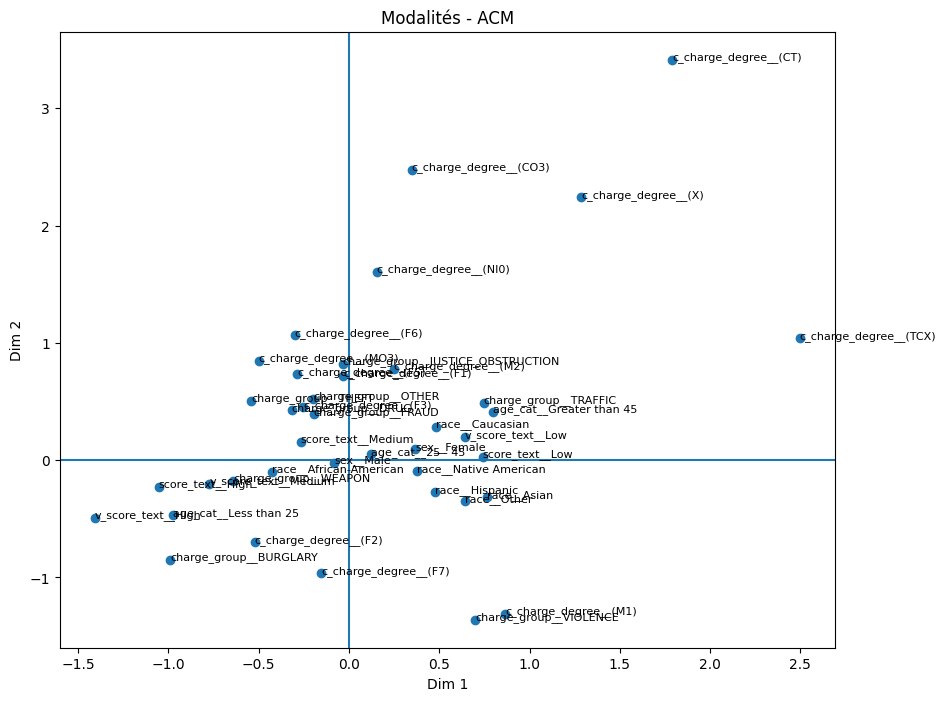

In [ ]:
coords = mca.column_coordinates(acm_df)

plt.figure(figsize=(10,8))

plt.scatter(coords[0], coords[1])

for i in coords.index:
    plt.text(
        coords.loc[i,0],
        coords.loc[i,1],
        str(i),
        fontsize=8
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Modalités - ACM")
plt.show()

Le premier plan factoriel met en évidence une opposition entre les individus jeunes (< 25 ans), associés à des scores COMPAS élevés et à des infractions telles que le cambriolage, le vol ou le port d'arme, et les individus plus âgés (> 45 ans), davantage associés à des scores de risque faibles et aux infractions routières. La première dimension reflète ainsi principalement un gradient de risque de récidive lié à l'âge. La deuxième dimension distingue certains types d'infractions, mais son interprétation reste plus prudente en raison de la présence de modalités rares dans la variable c_charge_degree (CT, TCX, X, CO3).

*Sauvegarde du dataset nettoyé*

Afin d'éviter de réexécuter l'ensemble des étapes de préparation des données, une sauvegarde intermédiaire du jeu de données nettoyé est réalisée. Cette approche permet de reprendre facilement l'analyse à partir de cet état et réduit le coût computationnel lors des expérimentations ultérieures.

In [ ]:
import pickle
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

with open("artifacts/df_clean.pkl", "wb") as f:
    pickle.dump(df_clean, f)

print("Dataset sauvegardé : artifacts/df_clean.pkl")

Dataset sauvegardé : artifacts/df_clean.pkl


In [ ]:
with open("artifacts/df_clean.pkl", "rb") as f:
    df_clean = pickle.load(f)

print(df_clean.shape)
df_clean.head()

(17496, 31)


,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,...,is_violent_recid,vr_charge_degree,vr_offense_date,vr_charge_desc,score_text,screening_date,v_decile_score,v_score_text,event,charge_group
0,Male,69,Greater than 45,Other,0,1,0,0,0,-1.0,...,0,NaN,NaN,NaN,Low,14/08/2013,1,Low,0,VIOLENCE
1,Male,69,Greater than 45,Other,0,1,0,0,0,-1.0,...,0,NaN,NaN,NaN,Low,14/08/2013,1,Low,0,VIOLENCE
3,Male,34,25 - 45,African-American,0,3,0,0,0,-1.0,...,1,(F3),05/07/2013,Felony Battery (Dom Strang),Low,27/01/2013,1,Low,1,VIOLENCE
4,Male,24,Less than 25,African-American,0,4,0,1,4,-1.0,...,0,NaN,NaN,NaN,Low,14/04/2013,3,Low,0,DRUG
5,Male,24,Less than 25,African-American,0,4,0,1,4,-1.0,...,0,NaN,NaN,NaN,Low,14/04/2013,3,Low,0,DRUG


La réouverture du fichier de sauvegarde confirme que le jeu de données a été correctement sérialisé et peut être réutilisé sans relancer les étapes précédentes du notebook.

**Céation du jeu de données de travail final**

In [ ]:
df_model = df_clean[
    [
        'sex',
        'age',
        'age_cat',
        'race',
        'juv_fel_count',
        'juv_misd_count',
        'juv_other_count',
        'priors_count',
        'days_b_screening_arrest',
        'c_days_from_compas',
        'c_charge_degree',
        'charge_group',
        'decile_score',
        'score_text',
        'v_decile_score',
        'v_score_text',
        'is_violent_recid',
        'is_recid'
    ]
].copy()

Afin de préparer les étapes de modélisation, un nouveau jeu de données df_model est créé à partir de df_clean. Il ne conserve que les variables explicatives retenues après les phases de nettoyage, d'analyse exploratoire, d'ACP et d'ACM, ainsi que la variable cible **is_recid**. Cette séparation permet de distinguer les données nettoyées des données effectivement utilisées pour la modélisation, tout en améliorant la lisibilité et la reproductibilité du projet.

In [ ]:
import pickle
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

with open("artifacts/df_model.pkl", "wb") as f:
    pickle.dump(df_model, f)

print("df_model sauvegardé.")

df_model sauvegardé.


**Choix de la stratégie d'encodage**

Les variables de df_model sont de nature mixte. Les variables numériques (âge, antécédents judiciaires, scores numériques, etc.) pourront être conservées sous leur forme actuelle après standardisation lorsque nécessaire. Les variables qualitatives devront être transformées en représentations numériques afin d'être exploitables par les algorithmes de réduction de dimension, de clustering et de modélisation.

In [ ]:
print(df_model.dtypes)

sex                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_days_from_compas         float64
c_charge_degree             object
charge_group                object
decile_score                 int64
score_text                  object
v_decile_score               int64
v_score_text                object
is_violent_recid             int64
is_recid                     int64
dtype: object


On constate que les variables qualitatives ne présentent pas toutes les mêmes caractéristiques. Les variables age_cat, score_text et v_score_text possèdent un ordre naturel et sont donc encodées à l'aide d'un encodage ordinal. À l'inverse, les variables sex, race, c_charge_degree et charge_group ne présentent aucun ordre entre leurs modalités ; elles sont transformées par One-Hot Encoding. Les variables numériques sont conservées dans leur format d'origine et seront standardisées avant les méthodes de réduction de dimension et de clustering.

**Préparation du préprocesseur**

Avant d'encoder les données, nous allons définir clairement les groupes de variables. Cela facilitera les modifications ultérieures.

In [ ]:
ordinal_cols = [
    "age_cat",
    "score_text",
    "v_score_text"
]

nominal_cols = [
    "sex",
    "race",
    "c_charge_degree",
    "charge_group"
]

numeric_cols = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "days_b_screening_arrest",
    "c_days_from_compas",
    "decile_score",
    "v_decile_score",
    "is_violent_recid"
]

Les variables sont regroupées selon leur nature afin d'appliquer à chacune un prétraitement adapté. Les variables ordinales seront encodées en conservant leur ordre naturel, les variables nominales seront transformées par One-Hot Encoding et les variables numériques seront standardisées après imputation des éventuelles valeurs manquantes. Cette organisation facilite la mise en œuvre d'un pipeline de prétraitement cohérent et reproductible.

**Construction du pipeline de prétraitement**

Trois pipelines de prétraitement seront définis en fonction de la nature des variables. Les variables numériques seront imputées par la médiane puis standardisées. Les variables ordinales seront imputées par la modalité la plus fréquente avant un encodage ordinal respectant leur ordre naturel. Les variables nominales seront également imputées puis transformées par One-Hot Encoding afin de représenter chaque modalité par une variable binaire.

- *Pipeline numérique*

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

- *Pipeline ordinal*

Pour les variables ordinales, il faut respecter l'ordre des catégories. Il ne faut pas laisser OrdinalEncoder décider automatiquement de l'ordre.

Si on ne précise pas les catégories, OrdinalEncoder les trie par ordre alphabétique. On obtiendrait par exemple :

High → 0

Low → 1

Medium → 2

ce qui est faux pour nos données. En imposant l'ordre, on respecte la signification des niveaux de risque.

In [ ]:
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[
        ["Less than 25", "25 - 45", "Greater than 45"],
        ["Low", "Medium", "High"],
        ["Low", "Medium", "High"]
    ]))
])

- *Pipeline nominal*

In [ ]:
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

On a maintenant construit les trois pipelines. L'étape suivante consiste à les assembler dans un seul préprocesseur, puis à l'appliquer à df_model.

**Prétraitement**

- *Construction du ColumnTransformer*

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("nom", nominal_pipeline, nominal_cols)
    ]
)

- *Séparation de la cible*

In [ ]:
X = df_model.drop(columns="is_recid")
y = df_model["is_recid"]

- *Application du prétraitement*

In [ ]:
X_prepared = preprocessor.fit_transform(X)

- *Vérification*

In [ ]:
print("Dimensions avant prétraitement :", X.shape)
print("Dimensions après prétraitement :", X_prepared.shape)

Dimensions avant prétraitement : (17496, 17)
Dimensions après prétraitement : (17496, 44)


Le prétraitement transforme les 17 variables explicatives en une matrice numérique de 44 variables. Cette augmentation est due au One-Hot Encoding appliqué aux variables nominales (sex, race, c_charge_degree et charge_group), qui crée une colonne binaire pour chaque modalité. Les variables ordinales conservent une seule colonne grâce à un encodage respectant leur ordre naturel, tandis que les variables numériques sont imputées puis standardisées. Les données sont désormais prêtes pour les méthodes de réduction de dimension et de clustering.

On va maintenant convertir la matrice prétraitée en DataFrame afin de conserver les noms des variables générées par le prétraitement. Cette représentation facilite l'interprétation des résultats, notamment lors des analyses de réduction de dimension, du clustering et de l'étude de l'importance des variables.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_prepared = pd.DataFrame(
    X_prepared,
    columns=feature_names,
    index=X.index
)

X_prepared.head()

,num__age,num__juv_fel_count,num__juv_misd_count,num__juv_other_count,num__priors_count,num__days_b_screening_arrest,num__c_days_from_compas,num__decile_score,num__v_decile_score,num__is_violent_recid,...,nom__c_charge_degree_(X),nom__charge_group_BURGLARY,nom__charge_group_DRUG,nom__charge_group_FRAUD,nom__charge_group_JUSTICE_OBSTRUCTION,nom__charge_group_OTHER,nom__charge_group_THEFT,nom__charge_group_TRAFFIC,nom__charge_group_VIOLENCE,nom__charge_group_WEAPON
0,3.020946,-0.169526,-0.194744,-0.241874,-0.765323,-0.064435,-0.178046,-1.375997,-1.165521,-0.287879,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.020946,-0.169526,-0.194744,-0.241874,-0.765323,-0.064435,-0.178046,-1.375997,-1.165521,-0.287879,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.004271,-0.169526,-0.194744,-0.241874,-0.765323,-0.064435,-0.178046,-0.694156,-1.165521,3.473682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.857636,-0.169526,-0.194744,1.625658,-0.018046,-0.064435,-0.178046,-0.353236,-0.401004,-0.287879,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.857636,-0.169526,-0.194744,1.625658,-0.018046,-0.064435,-0.178046,-0.353236,-0.401004,-0.287879,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- *Sauvegarde des données prétraitées*

In [ ]:
import pickle
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

with open("artifacts/X_prepared.pkl", "wb") as f:
    pickle.dump(X_prepared, f)

with open("artifacts/y.pkl", "wb") as f:
    pickle.dump(y, f)

print("X_prepared et y sauvegardés.")

X_prepared et y sauvegardés.


In [ ]:
with open("artifacts/X_prepared.pkl", "rb") as f:
    X_prepared = pickle.load(f)

with open("artifacts/y.pkl", "rb") as f:
    y = pickle.load(f)

## Clustering

**UMAP**

Après le prétraitement des données, une réduction de dimension est réalisée à l'aide de l'algorithme UMAP (Uniform Manifold Approximation and Projection). Contrairement à l'ACP, qui est une méthode linéaire, UMAP est capable de préserver les relations non linéaires entre les observations. Cette représentation permettra d'explorer la structure des données et d'identifier d'éventuels groupes naturels avant l'étape de clustering.

- *Construction d'UMAP*

In [ ]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_prepared)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- *Visualisation*

Afin de faciliter l'interprétation de la projection UMAP, les observations sont colorées selon deux variables d'intérêt. La première représentation met en évidence la répartition des individus selon leur statut de récidive (is_recid), tandis que la seconde illustre la distribution des scores COMPAS (decile_score). Cette double visualisation permet d'évaluer si la structure révélée par UMAP est cohérente avec les informations utilisées dans l'étude.

*UMAP coloré par la récidive*

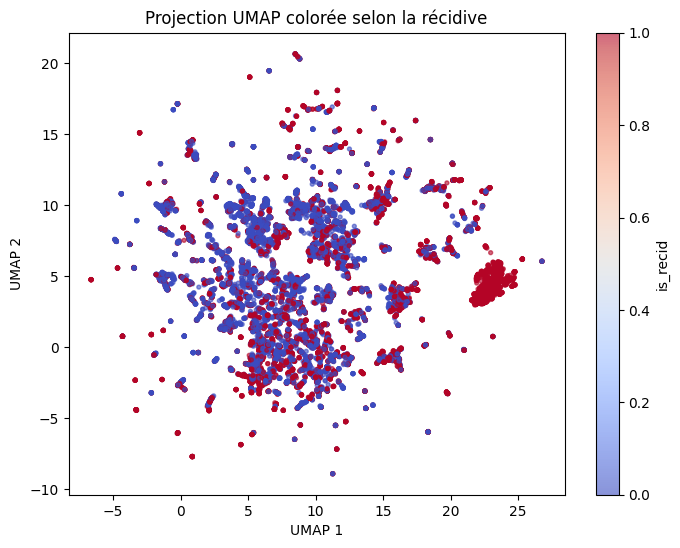

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y,
    cmap="coolwarm",
    s=8,
    alpha=0.6
)

plt.colorbar(label="is_recid")
plt.title("Projection UMAP colorée selon la récidive")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

*UMAP coloré par le score COMPAS*

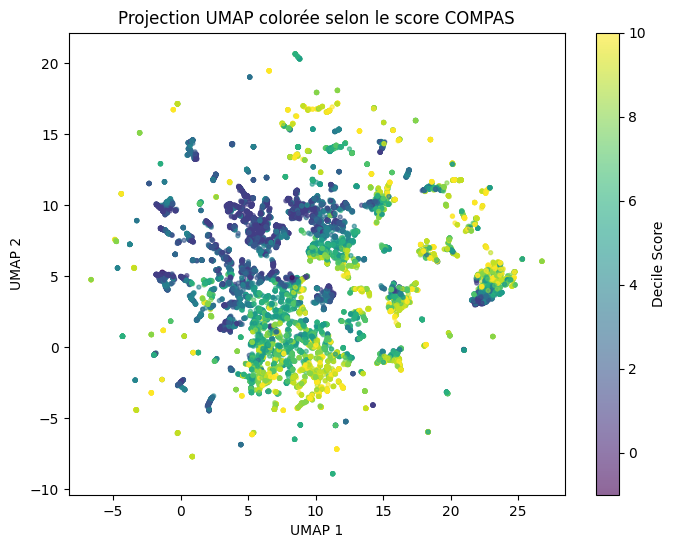

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df_model["decile_score"],
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.colorbar(label="Decile Score")

plt.title("Projection UMAP colorée selon le score COMPAS")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

plusieurs regroupements d'observations. La coloration selon la variable is_recid montre que les individus récidivistes et non récidivistes restent largement mélangés dans l'espace projeté. Aucun groupe n'est exclusivement constitué de récidivistes ou de non-récidivistes, ce qui suggère que la récidive ne peut pas être expliquée par une séparation simple des individus dans l'espace des variables étudiées.

La seconde représentation, colorée selon le score COMPAS, révèle en revanche un gradient plus marqué. Certaines zones de la projection regroupent majoritairement des individus présentant des scores COMPAS élevés, tandis que d'autres sont associées à des scores plus faibles. Cette organisation indique que les variables utilisées pour construire le score COMPAS structurent davantage les données que la variable de récidive observée.

Dans l'ensemble, UMAP confirme l'existence d'une organisation complexe des individus, sans séparation nette entre récidivistes et non-récidivistes, ce qui justifie le recours à des méthodes de clustering afin d'explorer d'éventuels profils de population.

In [ ]:
import pickle

with open("umap_embedding.pkl", "wb") as f:
    pickle.dump(X_umap, f)

print("Embedding UMAP sauvegardé.")

Embedding UMAP sauvegardé.


- **T-SNE**

En complément d'UMAP, une projection par t-SNE est réalisée afin d'explorer la structure locale des données. Les observations sont colorées selon la variable de récidive (is_recid) puis selon le score COMPAS (decile_score) afin d'évaluer si cette méthode met davantage en évidence des regroupements d'individus présentant des caractéristiques similaires.

*Calcul*

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_prepared)

print(X_tsne.shape)

(17496, 2)


In [ ]:
import pickle

with open("tsne_embedding.pkl", "wb") as f:
    pickle.dump(X_tsne, f)

print("Embedding t-SNE sauvegardé.")

Embedding t-SNE sauvegardé.


*Visualisation selon la récidive*

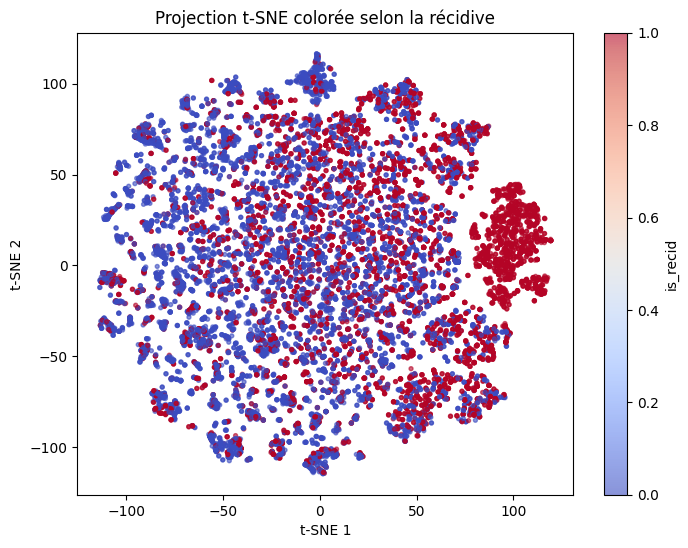

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y,
    cmap="coolwarm",
    s=8,
    alpha=0.6
)

plt.colorbar(label="is_recid")

plt.title("Projection t-SNE colorée selon la récidive")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.show()

*Visualisation selon le score COMPAS*

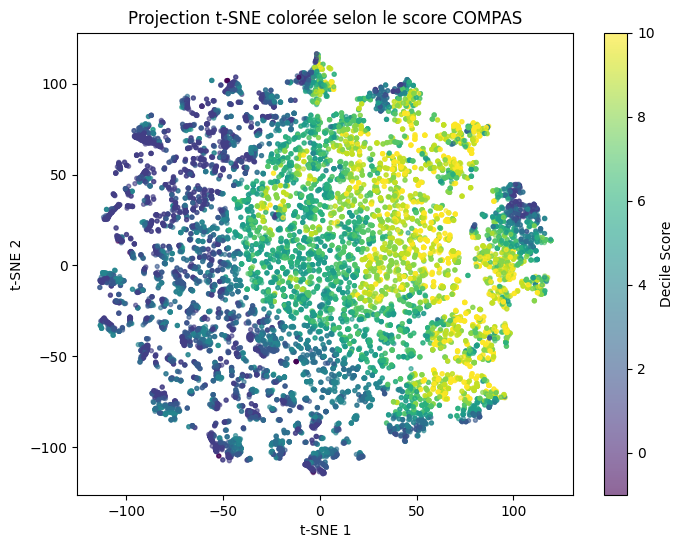

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df_model["decile_score"],
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.colorbar(label="Decile Score")

plt.title("Projection t-SNE colorée selon le score COMPAS")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.show()

La projection obtenue par t-SNE met en évidence une structuration locale plus marquée que celle observée avec UMAP. Plusieurs amas d'individus apparaissent distinctement, bien que la majorité des récidivistes et des non-récidivistes demeurent mélangés dans l'espace projeté. On observe toutefois un groupe particulièrement compact composé majoritairement d'individus récidivistes, ce qui suggère l'existence d'un profil spécifique partageant des caractéristiques communes. Cette observation sera approfondie dans la section consacrée au clustering afin de déterminer si ces regroupements correspondent à des profils criminels distincts.

**kMeans**

- *Méthode du coude*

Afin de déterminer le nombre optimal de groupes, la méthode du coude est appliquée. Cette approche consiste à observer l'évolution de l'inertie intra-classe lorsque le nombre de clusters augmente. Le choix du nombre de clusters correspond généralement au point où la diminution de l'inertie devient moins importante.

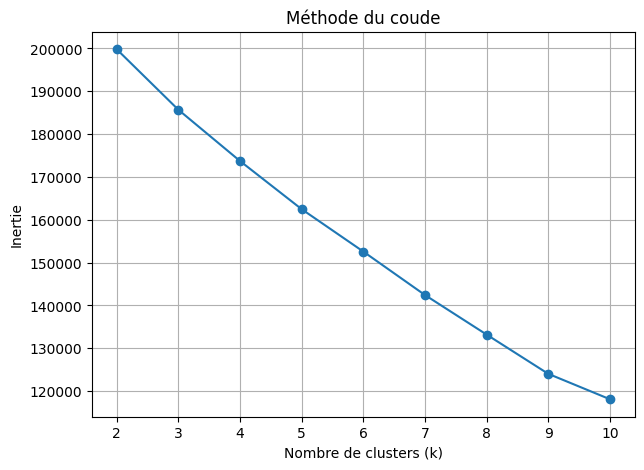

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_prepared)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K, inertia, marker='o')

plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.grid(True)
plt.show()

La méthode du coude ne met pas en évidence un point de rupture clairement identifiable. L'inertie diminue de manière relativement régulière lorsque le nombre de clusters augmente, sans véritable changement de pente. Cette méthode ne permet donc pas, à elle seule, de déterminer le nombre optimal de clusters. Une analyse complémentaire à l'aide du score de silhouette est réalisée afin de guider ce choix.

- *score de silhouette*

Afin de compléter la méthode du coude, le score de silhouette est calculé pour plusieurs valeurs de k. Cet indicateur mesure à quel point les individus sont proches des observations de leur propre cluster et éloignés des autres clusters. La valeur de k maximisant ce score est généralement retenue comme le meilleur compromis entre cohésion interne et séparation des groupes.

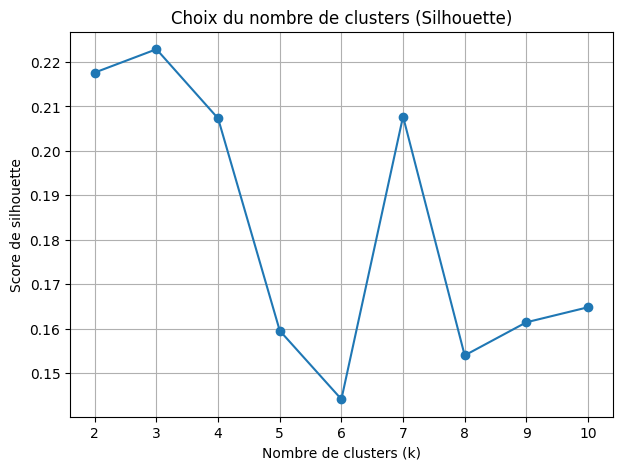

In [ ]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_prepared)
    score = silhouette_score(X_prepared, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(K, silhouette_scores, marker="o")

plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters (Silhouette)")
plt.grid(True)
plt.show()

Le score de silhouette atteint sa valeur maximale pour k = 3, indiquant une meilleure cohésion interne des groupes et une meilleure séparation entre les clusters. Bien qu'un second maximum local soit observé pour k = 7, celui-ci reste inférieur au score obtenu avec trois clusters. En cohérence avec cette analyse, le choix de 3 clusters est retenu pour la suite de l'étude.

- *construction des clusters*

On va maintenant entraîner le modèle K-Means avec 3 clusters.

Le modèle K-Means est ensuite entraîné en retenant trois clusters, conformément au résultat obtenu avec le score de silhouette. Chaque individu est ainsi affecté au groupe dont il est le plus proche dans l'espace des variables prétraitées.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_prepared)

df_model["cluster"] = clusters

df_model["cluster"].value_counts().sort_index()

,count
cluster,
0,9493
1,6665
2,1338


L'algorithme K-Means partitionne les données en trois groupes de tailles différentes. Le cluster 0 regroupe environ 54 % des individus, le cluster 1 près de 38 %, tandis que le cluster 2 représente seulement 8 % de l'échantillon. Cette répartition suggère l'existence d'un profil minoritaire qui sera étudié plus en détail lors du profilage des clusters.

- Maintenant on doit répondre à la question : Qui sont les individus de chaque cluster ?

C'est une partie qui apporte de la valeur.

1. Variables numériques

In [ ]:
cluster_num = (
    df_model
    .groupby("cluster")[
        [
            "age",
            "priors_count",
            "juv_fel_count",
            "juv_misd_count",
            "juv_other_count",
            "decile_score",
            "v_decile_score",
            "days_b_screening_arrest",
            "c_days_from_compas"
        ]
    ]
    .mean()
    .round(2)
)

cluster_num

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,decile_score,v_decile_score,days_b_screening_arrest,c_days_from_compas
cluster,,,,,,,,,
0,38.30,2.65,0.01,0.01,0.02,3.03,2.24,0.48,58.98
1,28.41,5.93,0.18,0.20,0.26,7.65,6.38,9.00,60.76
2,30.69,5.21,0.13,0.25,0.23,6.26,5.29,7.73,33.33


Les moyennes des variables numériques mettent en évidence trois profils distincts. Le cluster 0 regroupe les individus les plus âgés, présentant peu d'antécédents judiciaires et des scores COMPAS faibles, ce qui correspond à un profil de faible risque de récidive. À l'inverse, le cluster 1 rassemble les individus les plus jeunes, ayant le plus grand nombre d'antécédents ainsi que les scores COMPAS les plus élevés, traduisant un profil de risque important. Enfin, le cluster 2 présente des caractéristiques intermédiaires, avec des niveaux d'antécédents et de risque compris entre les deux autres groupes.

On va maintenant répondre aux questions comme :

- quel cluster contient le plus de récidivistes (is_recid) ?
- quel cluster est principalement composé de jeunes ?
- quel cluster est associé aux infractions de type DRUG, VIOLENCE, THEFT, etc. ?

C'est cette analyse des variables catégorielles qui donnera une véritable identité à chaque cluster.

2. Cas de **even**

In [ ]:
pd.crosstab(
    df_model["cluster"],
    df_model["is_recid"],
    normalize="index"
).round(3) * 100

is_recid,0,1
cluster,,
0,66.4,33.6
1,41.6,58.4
2,0.0,100.0


Les proportions de récidive diffèrent fortement selon les clusters. Le cluster 0 est majoritairement composé de non-récidivistes (66,4 %), tandis que le cluster 1 présente une majorité de récidivistes (58,4 %). Le cluster 2 se distingue par une proportion de récidive de 100 %. Toutefois, ce dernier représente une faible part de l'échantillon et son interprétation doit être réalisée avec prudence, cette particularité pouvant également refléter certaines caractéristiques propres au jeu de données. Ces résultats montrent néanmoins que les groupes identifiés par le clustering sont fortement associés au phénomène de récidive.

In [ ]:
pd.crosstab(
    df_model["cluster"],
    df_clean.loc[df_model.index, "event"],
    normalize="index"
).round(3) * 100

event,0,1
cluster,,
0,100.0,0.0
1,100.0,0.0
2,38.9,61.1


On constate que :

- les clusters 0 et 1 sont entièrement composés d'individus avec event = 0 ;
- seul le cluster 2 contient des individus ayant event = 1, mais pas exclusivement (39 % ont event = 0).

En effet, le fait que le cluster 2 contienne 100 % de récidivistes (is_recid = 1) n'est pas uniquement dû à la variable event. Le clustering a réellement identifié un sous-groupe très particulier.

Dans la suite on va vérifier les types d'infractions qu'on retrouve dans chaque cluster.

 *Profil des infractions*

In [ ]:
pd.crosstab(
    df_model["cluster"],
    df_model["charge_group"],
    normalize="index"
).round(3) * 100

charge_group,BURGLARY,DRUG,FRAUD,JUSTICE_OBSTRUCTION,OTHER,THEFT,TRAFFIC,VIOLENCE,WEAPON
cluster,,,,,,,,,
0,3.1,15.0,1.2,0.9,29.4,10.0,12.5,27.2,0.7
1,6.7,20.8,1.2,0.8,33.2,15.1,6.3,15.1,0.9
2,3.4,15.5,1.0,0.6,30.8,9.0,5.7,32.6,1.3


L'analyse des types d'infractions confirme les différences observées entre les clusters. Le cluster 0 est davantage associé aux infractions routières et présente le profil de risque le plus faible. Le cluster 1 se distingue par une proportion plus importante de délits liés aux stupéfiants, aux vols et aux cambriolages, en cohérence avec son niveau élevé de récidive et ses scores COMPAS plus importants. Enfin, le cluster 2, bien que minoritaire, est principalement caractérisé par des infractions violentes et une proportion de récidive particulièrement élevée.

3. Cas de l'âge par catégorie (**age_cat**)

Cette analyse permettra de confirmer si le cluster de faible risque est majoritairement composé de personnes de plus de 45 ans et si le cluster de risque élevé est principalement constitué de jeunes adultes.

In [ ]:
pd.crosstab(
    df_model["cluster"],
    df_model["age_cat"],
    normalize="index"
).round(3) * 100

age_cat,25 - 45,Greater than 45,Less than 25
cluster,,,
0,60.1,30.4,9.6
1,52.0,6.5,41.5
2,59.3,10.4,30.3


La répartition des classes d'âge confirme les profils précédemment identifiés. Le cluster 0 regroupe davantage d'individus âgés de plus de 45 ans, tandis que le cluster 1 est caractérisé par une forte proportion de jeunes de moins de 25 ans. Le cluster 2 présente un profil intermédiaire. Ces résultats sont cohérents avec les analyses de l'ACP, de l'ACM et des variables numériques, qui mettaient déjà en évidence le rôle important de l'âge dans la structuration des données.


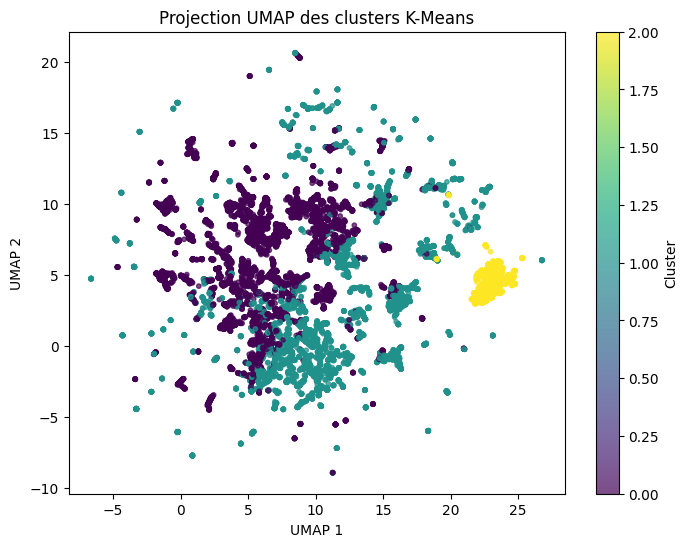

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df_model["cluster"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP des clusters K-Means")

plt.colorbar(label="Cluster")

plt.show()

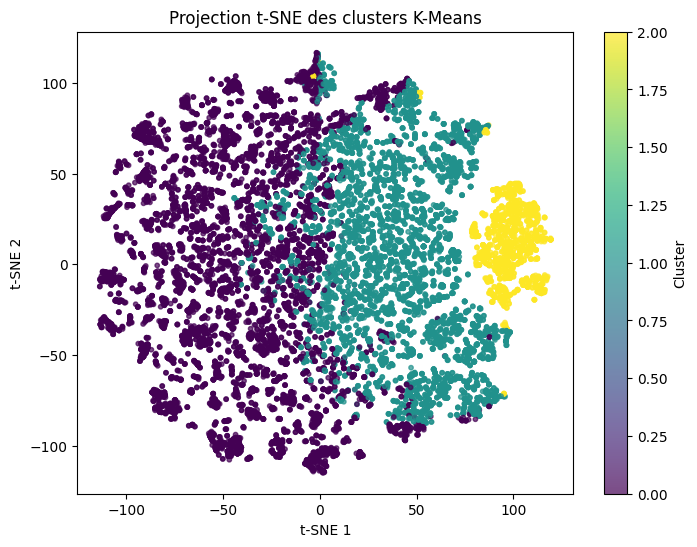

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df_model["cluster"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Projection t-SNE des clusters K-Means")

plt.colorbar(label="Cluster")

plt.show()

La projection t-SNE met clairement en évidence les trois groupes identifiés par l'algorithme K-Means. Deux clusters regroupent la majorité des individus, tandis qu'un troisième cluster apparaît nettement isolé. Cette séparation confirme que les profils découverts par le clustering correspondent à des structures réelles présentes dans les données, même si certaines frontières demeurent progressives entre les groupes principaux.

# Importance des variables

L'objectif de cette partie est de répondre à la question : Quelles variables expliquent le mieux la récidive ?

Cela permettra :

- de vérifier que les scores COMPAS sont effectivement importants ;
- de voir si certaines variables sont peu informatives ;
- de justifier les variables utilisées dans les modèles prédictifs.

Pour cela, au lieu de calculer directement une importance avec un seul modèle (par exemple Random Forest), on va procéder en deux temps.

- *Random Forest (importance par impurité)*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df_model.drop(columns="is_recid")
y = df_model["is_recid"]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_prepared, y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

- *Permutation Importance*

Ici, on veut savoir si le classement obtenu avec la Random Forest est confirmé ou non.

In [ ]:
# Variables explicatives préparées
X_rf = X_prepared

# Variable cible
y_rf = df_model["is_recid"]

# Entraînement
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y_rf)

# Importance
importance = pd.DataFrame({
    "Variable": X_rf.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Variable,Importance
0,num__age,0.155769
4,num__priors_count,0.128609
7,num__decile_score,0.085899
8,num__v_decile_score,0.073849
6,num__c_days_from_compas,0.073782
5,num__days_b_screening_arrest,0.073521
9,num__is_violent_recid,0.069895
11,ord__score_text,0.031864
10,ord__age_cat,0.022147
12,ord__v_score_text,0.021715


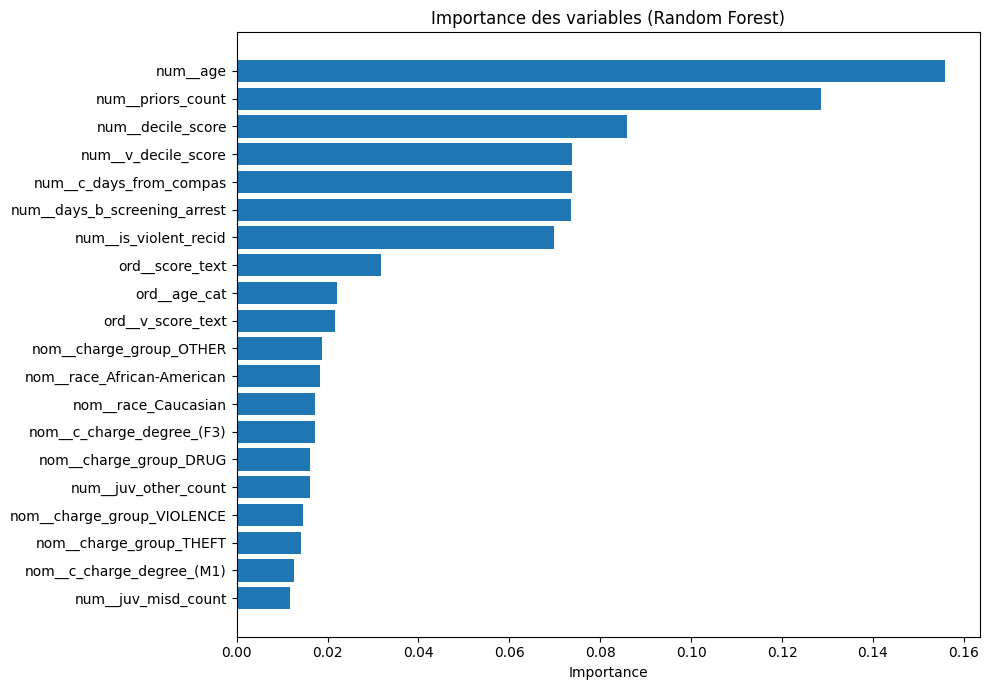

In [ ]:
top = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top["Variable"][::-1],
    top["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Importance des variables (Random Forest)")

plt.tight_layout()

plt.show()

- *Regrouper les importances par variable d'origine*

In [ ]:
importance_grouped = importance.copy()

importance_grouped["Variable"] = (
    importance_grouped["Variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("ord__", "", regex=False)
    .str.replace("nom__", "", regex=False)
)

importance_grouped["Variable"] = (
    importance_grouped["Variable"]
    .str.split("_")
    .str[:2]
    .str.join("_")
)

importance_grouped = (
    importance_grouped
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

importance_groupedimportance_grouped = importance.copy()

importance_grouped["Variable"] = (
    importance_grouped["Variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("ord__", "", regex=False)
    .str.replace("nom__", "", regex=False)
)

importance_grouped["Variable"] = (
    importance_grouped["Variable"]
    .str.split("_")
    .str[:2]
    .str.join("_")
)

importance_grouped = (
    importance_grouped
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

importance_grouped

,Variable,Importance
0,age,0.155769
11,priors_count,0.128609
4,charge_group,0.091846
6,decile_score,0.085899
21,v_decile,0.073849
3,c_days,0.073782
5,days_b,0.073521
7,is_violent,0.069895
2,c_charge,0.058569
18,score_text,0.031864


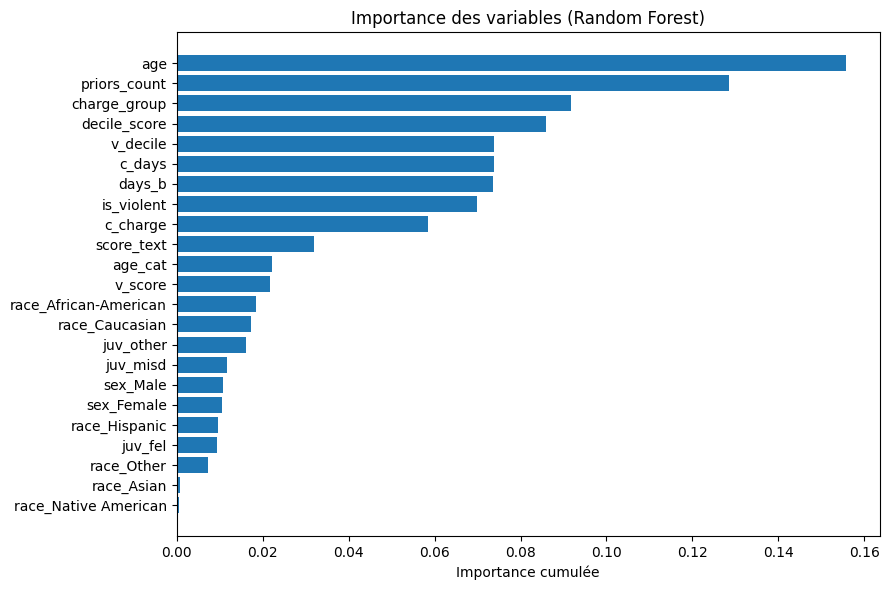

In [ ]:
plt.figure(figsize=(9,6))

plt.barh(
    importance_grouped["Variable"][::-1],
    importance_grouped["Importance"][::-1]
)

plt.xlabel("Importance cumulée")
plt.title("Importance des variables (Random Forest)")

plt.tight_layout()
plt.show()

L'analyse de l'importance des variables à l'aide d'une forêt aléatoire montre que l'âge (age) constitue la variable la plus influente pour prédire la récidive, suivi du nombre d'antécédents judiciaires (priors_count). Les scores COMPAS (decile_score et v_decile_score) ainsi que certaines variables temporelles (c_days_from_compas et days_b_screening_arrest) présentent également une contribution importante au modèle. Les variables décrivant le type d'infraction (charge_group, c_charge_degree) apportent une information complémentaire, tandis que les variables démographiques telles que le sexe et la race ont une influence relativement faible. Ces résultats confirment que l'historique judiciaire et l'évaluation du risque réalisée par COMPAS constituent les principaux facteurs associés à la prédiction de la récidive dans ce jeu de données.

# Modélisation

L'objectif de cette partie est de construire plusieurs modèles de classification capables de prédire la récidive d'un individu (`is_recid`). Afin de garantir une comparaison équitable entre les modèles, les données sont séparées en un ensemble d'entraînement et un ensemble de test. Une répartition stratifiée est utilisée afin de conserver la même proportion de récidive dans les deux ensembles.

**Séparation Train/Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    df_model["is_recid"],
    test_size=0.20,
    stratify=df_model["is_recid"],
    random_state=42
)

print("Jeu d'entraînement :", X_train.shape)
print("Jeu de test :", X_test.shape)

print("\nRépartition de la cible")
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

Jeu d'entraînement : (13996, 44)
Jeu de test : (3500, 44)

Répartition de la cible
is_recid
0    0.519
1    0.481
Name: proportion, dtype: float64
is_recid
0    0.519
1    0.481
Name: proportion, dtype: float64


Les données ont été séparées en un ensemble d'entraînement (80 %) et un ensemble de test (20 %). Une séparation stratifiée a été utilisée afin de conserver la même proportion de récidive dans les deux ensembles. On observe que la classe *is_recid = 0* représente environ 51,9 % des observations, contre 48,1 % pour *is_recid = 1*, aussi bien dans les données d'entraînement que dans les données de test. Cette répartition garantit que les performances des modèles seront évaluées sur un échantillon représentatif de la distribution initiale des données.

**Régression Logistique**

La régression logistique constitue un modèle de référence largement utilisé pour les problèmes de classification binaire. Bien qu'elle repose sur une hypothèse de relation linéaire entre les variables explicatives et le logarithme des probabilités, elle offre une bonne interprétabilité et permet d'établir une première base de comparaison avec des modèles plus complexes.

- *Entraînement*

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

- *Prédictions*

In [ ]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

- *Métriques*

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_log),3))
print("Precision:", round(precision_score(y_test, y_pred_log),3))
print("Recall   :", round(recall_score(y_test, y_pred_log),3))
print("F1-score :", round(f1_score(y_test, y_pred_log),3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_log),3))

Accuracy : 0.695
Precision: 0.712
Recall   : 0.616
F1-score : 0.66
ROC-AUC  : 0.772


- *Rapport de classification*

In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.68      0.77      0.72      1816
           1       0.71      0.62      0.66      1684

    accuracy                           0.70      3500
   macro avg       0.70      0.69      0.69      3500
weighted avg       0.70      0.70      0.69      3500



- *Matrice de confusion*

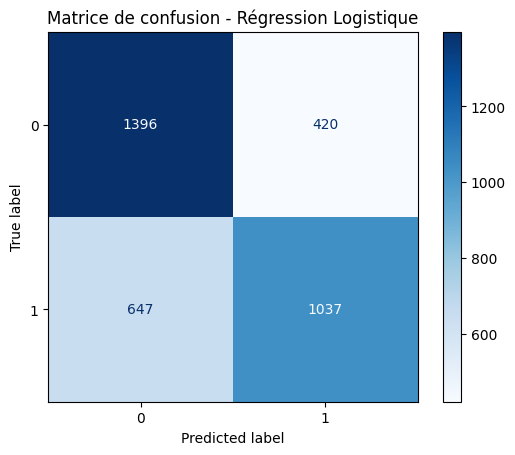

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues"
)

plt.title("Matrice de confusion - Régression Logistique")
plt.show()

- *Courbe ROC*

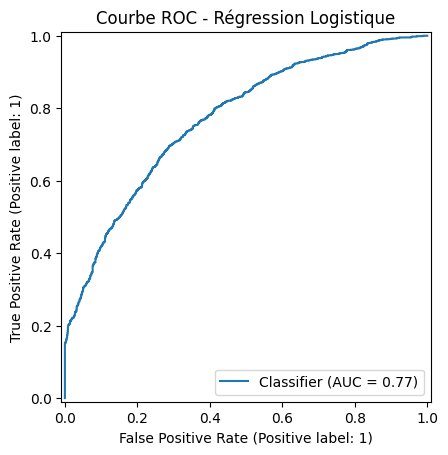

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log
)

plt.title("Courbe ROC - Régression Logistique")
plt.show()

La régression logistique obtient une accuracy de 69,5 % et une aire sous la courbe ROC (ROC-AUC) de 0,772, ce qui traduit une capacité de discrimination satisfaisante entre les individus récidivistes et non récidivistes. La précision atteint 71,2 %, tandis que le rappel est de 61,6 %, indiquant que le modèle identifie correctement une majorité des récidivistes, mais laisse encore échapper une part non négligeable d'entre eux.

La matrice de confusion montre que le modèle classe correctement 1 396 individus non récidivistes et 1 037 récidivistes. En revanche, 647 récidivistes sont prédits à tort comme non récidivistes (faux négatifs), tandis que 420 non récidivistes sont prédits à tort comme récidivistes (faux positifs). Cette observation est particulièrement importante dans le contexte judiciaire, où les faux positifs et les faux négatifs n'ont pas les mêmes conséquences et devront être étudiés plus en détail dans l'analyse des biais et de l'équité.

**Random Forest**

La forêt aléatoire (Random Forest) est un modèle d'ensemble reposant sur la combinaison de plusieurs arbres de décision construits sur des échantillons aléatoires des données. Cette approche permet généralement d'obtenir de meilleures performances prédictives tout en réduisant le risque de surapprentissage. Ce modèle servira également de base pour l'analyse d'explicabilité et d'équité réalisée dans la suite du projet.

- *Entraînement*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

- *Prédictions*

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

- *Métriques*

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("F1-score :", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 3))

Accuracy : 0.914
Precision: 0.902
Recall   : 0.921
F1-score : 0.912
ROC-AUC  : 0.967


- *Rapport de classification*

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1816
           1       0.90      0.92      0.91      1684

    accuracy                           0.91      3500
   macro avg       0.91      0.91      0.91      3500
weighted avg       0.91      0.91      0.91      3500



- *Matrice de confusion*

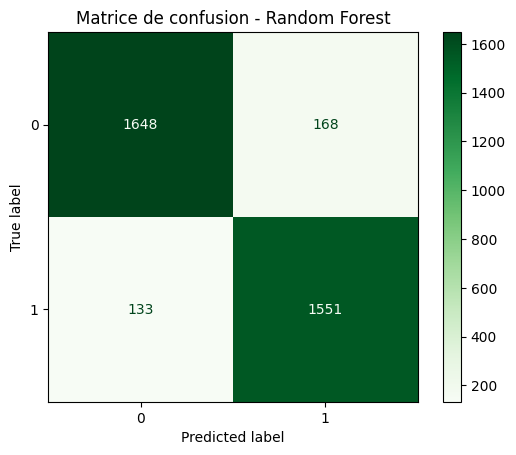

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Matrice de confusion - Random Forest")
plt.show()

- *Courbe ROC*

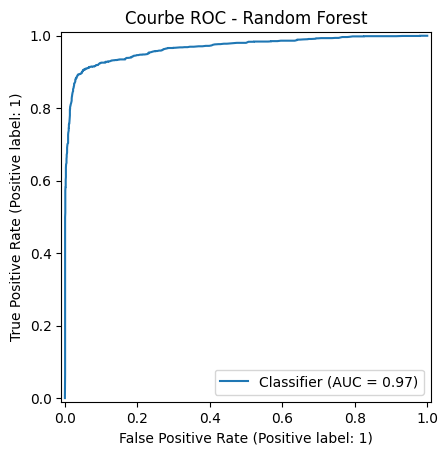

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Courbe ROC - Random Forest")
plt.show()

Le modèle Random Forest améliore très fortement les performances par rapport à la régression logistique. Il atteint une accuracy de 91,4 % ainsi qu'une aire sous la courbe ROC (ROC-AUC) de 0,967, traduisant une excellente capacité à distinguer les individus récidivistes des non-récidivistes.

La précision (90,2 %) et le rappel (92,1 %) sont élevés et relativement équilibrés, ce qui indique que le modèle détecte efficacement les individus susceptibles de récidiver tout en limitant les erreurs de classification.

La matrice de confusion confirme ces résultats : 1 648 non-récidivistes et 1 551 récidivistes sont correctement classés. Seuls 168 faux positifs et 133 faux négatifs sont observés. Comparativement à la régression logistique, le nombre d'erreurs diminue fortement, ce qui montre que la forêt aléatoire capture des relations non linéaires entre les variables explicatives que le modèle linéaire ne parvenait pas à modéliser.

**Gradient Boosting**

Le Gradient Boosting est une méthode d'ensemble reposant sur la construction séquentielle de plusieurs arbres de décision. Contrairement au Random Forest, qui construit ses arbres de manière indépendante, chaque nouvel arbre cherche à corriger les erreurs commises par les précédents. Cette stratégie permet généralement d'améliorer les performances prédictives sur des problèmes de classification complexes. Les résultats obtenus seront comparés à ceux de la régression logistique et du Random Forest afin de sélectionner le modèle le plus adapté pour les analyses d'explicabilité et d'équité.

- *Entraînement*

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

- *Prédictions*

In [ ]:
y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

- *Métriques-

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_gb),3))
print("Precision:", round(precision_score(y_test, y_pred_gb),3))
print("Recall   :", round(recall_score(y_test, y_pred_gb),3))
print("F1-score :", round(f1_score(y_test, y_pred_gb),3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_gb),3))

Accuracy : 0.718
Precision: 0.72
Recall   : 0.678
F1-score : 0.698
ROC-AUC  : 0.797


- *Rapport de classification*

In [ ]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      1816
           1       0.72      0.68      0.70      1684

    accuracy                           0.72      3500
   macro avg       0.72      0.72      0.72      3500
weighted avg       0.72      0.72      0.72      3500



- *Matrice de confusion*

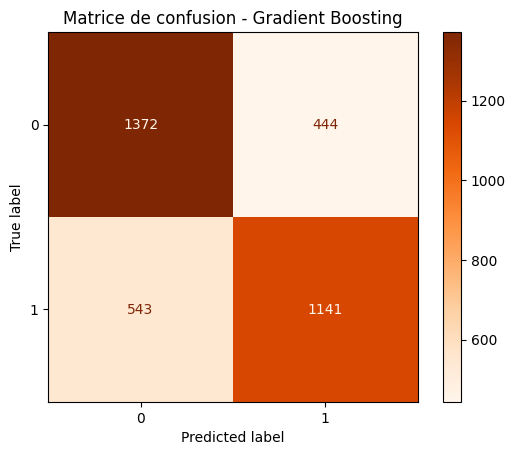

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    cmap="Oranges"
)

plt.title("Matrice de confusion - Gradient Boosting")
plt.show()

- *Courbe ROC*

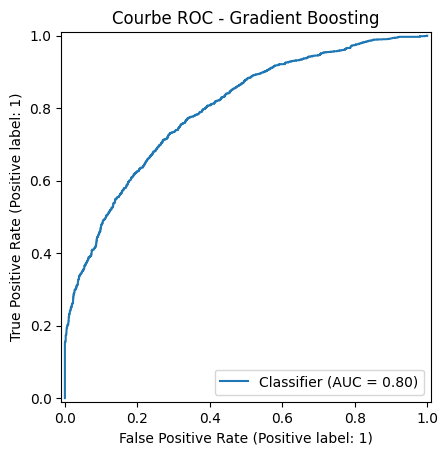

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb
)

plt.title("Courbe ROC - Gradient Boosting")
plt.show()

Le Gradient Boosting améliore légèrement les performances par rapport à la régression logistique en atteignant une accuracy de 71,8 % contre 69,5 %. Les indicateurs de précision (72,0 %), de rappel (67,8 %) et de F1-score (69,8 %) montrent une meilleure capacité à identifier les individus récidivistes tout en conservant un bon équilibre entre les deux classes.

Toutefois, ses performances restent nettement inférieures à celles du Random Forest, qui obtient une accuracy de 91,4 % ainsi qu'une ROC-AUC de 0,967. Ce dernier apparaît donc comme le modèle le plus performant sur ce jeu de données et sera retenu pour la suite des analyses portant sur l'explicabilité et l'équité.

**Comparaison des trois modèles**

Les trois modèles entraînés sont maintenant comparés à l'aide des principales métriques de classification. Cette comparaison permet de sélectionner le modèle offrant le meilleur compromis entre capacité de prédiction et robustesse avant d'entreprendre les analyses d'explicabilité et d'équité.

In [ ]:
results = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "Gradient Boosting",
        "Random Forest"
    ],
    "Accuracy": [0.695, 0.718, 0.914],
    "Precision": [0.712, 0.720, 0.902],
    "Recall": [0.616, 0.678, 0.921],
    "F1-score": [0.660, 0.698, 0.912],
    "ROC-AUC": [0.772, 0.797, 0.967]
})

results.sort_values("Accuracy", ascending=False)

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.914,0.902,0.921,0.912,0.967
1,Gradient Boosting,0.718,0.720,0.678,0.698,0.797
0,Régression Logistique,0.695,0.712,0.616,0.660,0.772


**Conclusion**

Les résultats montrent que le Random Forest est le modèle le plus performant parmi les trois approches étudiées. Il dépasse largement la régression logistique et le Gradient Boosting sur l'ensemble des indicateurs de performance. Cette supériorité s'explique par sa capacité à modéliser des relations non linéaires et des interactions complexes entre les variables.



Le Random Forest ayant obtenu les meilleures performances, il est retenu pour la suite de l'étude. Afin de comprendre les mécanismes de décision du modèle, une analyse d'explicabilité est réalisée à l'aide de la méthode SHAP.

# Explicabilité du modèle

Les performances élevées d'un modèle ne suffisent pas à garantir sa fiabilité ou son acceptabilité dans un contexte de prise de décision. Il est également nécessaire de comprendre les facteurs qui influencent les prédictions réalisées. Cette étape utilise la méthode SHAP (SHapley Additive exPlanations), fondée sur la théorie des jeux coopératifs, afin de quantifier la contribution de chaque variable aux prédictions du modèle Random Forest retenu précédemment.

In [ ]:
!pip install shap -q

In [ ]:
import shap

**Création de l'explainer**

In [ ]:
import shap

# On utilise un échantillon du jeu de test
X_shap = X_test.sample(n=500, random_state=42)

In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_shap)

**graphique d'importance globale**

In [ ]:
X_shap_display = X_shap.copy()

X_shap_display.columns = [
    c.replace("num__", "")
     .replace("ord__", "")
     .replace("nom__", "")
     .replace("v_decile_score", "v_decile")
     .replace("c_days_from_compas", "c_days")
     .replace("days_b_screening_arrest", "days_b")
     .replace("juv_fel_count", "juv_fel")
     .replace("juv_misd_count", "juv_misd")
     .replace("juv_other_count", "juv_other")
     .replace("is_violent_recid", "violent_recid")
    for c in X_shap.columns
]

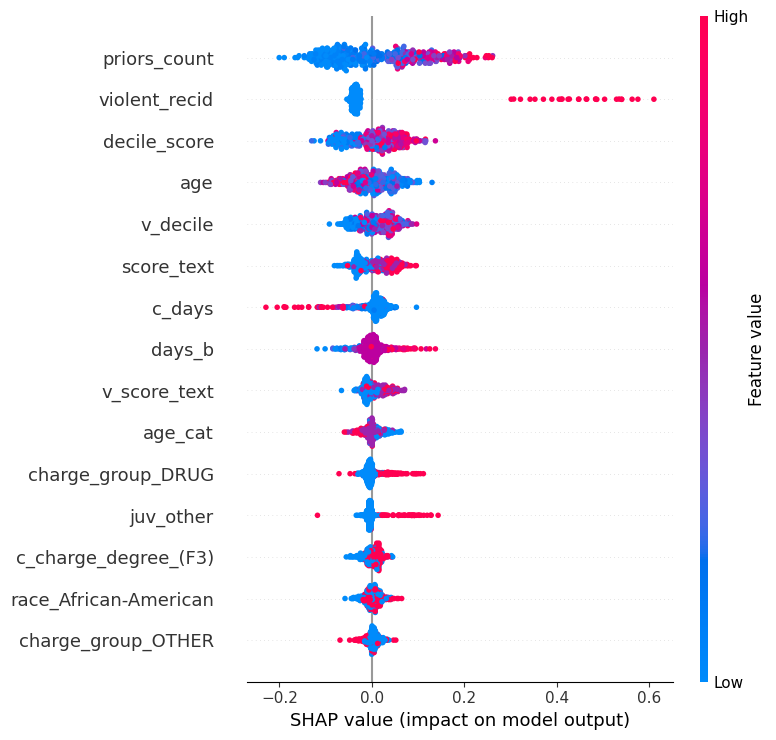

In [ ]:
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_shap_display,
    max_display=15
)

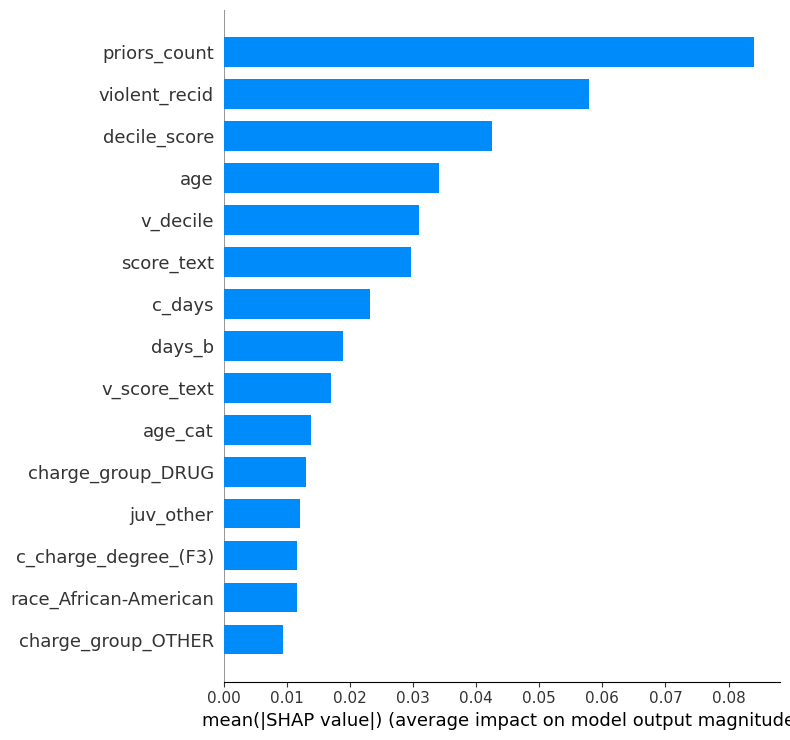

In [ ]:
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_shap_display,
    plot_type="bar",
    max_display=15
)

Le graphique SHAP présente l'importance moyenne des variables dans les prédictions du modèle Random Forest. Contrairement aux importances classiques fournies par le modèle, les valeurs SHAP quantifient la contribution réelle de chaque variable à la prédiction en tenant compte des interactions avec les autres variables.

Les résultats montrent que le nombre d'antécédents judiciaires (`priors_count`) est la variable la plus influente dans la prédiction de la récidive. Elle est suivie par l'indicateur de récidive violente (`is_violent_recid`), le score COMPAS (`decile_score`), l'âge (`age`) ainsi que le score de violence (`v_decile_score`).

Les variables catégorielles telles que le groupe d'infraction (`charge_group`), le degré de l'infraction (`c_charge_degree`) ou la race contribuent également aux prédictions, mais leur influence demeure plus faible. Cette hiérarchie est cohérente avec les analyses exploratoires précédentes, qui avaient déjà mis en évidence le rôle prépondérant des antécédents judiciaires, de l'âge et des scores COMPAS dans la différenciation des profils de récidive.

## Analyse des biais du modèle

L'objectif de cette étape est d'évaluer si les prédictions du modèle présentent des différences selon certains groupes d'individus. Conformément aux recommandations en matière d'équité des modèles d'apprentissage automatique, nous analysons successivement les performances selon le sexe, la race et la catégorie d'âge.

Dans un premier temps, nous évaluons la proportion de prédictions positives produites par le modèle pour chaque groupe (parité démographique). Nous étudierons ensuite les performances du modèle à l'aide d'indicateurs d'équité tels que le taux de vrais positifs (True Positive Rate), qui sera utilisé dans la partie suivante pour évaluer l'égalité des chances.

**Parité démographique selon la race**

Avant de calculer des métriques complexes, regardons simplement :

   Le modèle prédit-il plus souvent la récidive pour certains groupes ?

In [ ]:
# Jeu de test sous forme de DataFrame
X_test_original = df_model.loc[X_test.index].copy()

# Prédictions du Random Forest
X_test_original["prediction"] = rf_model.predict(X_test)

In [ ]:
(
    X_test_original
    .groupby("race")["prediction"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

,prediction
race,
African-American,0.565
Caucasian,0.436
Native American,0.429
Other,0.366
Hispanic,0.314
Asian,0.312


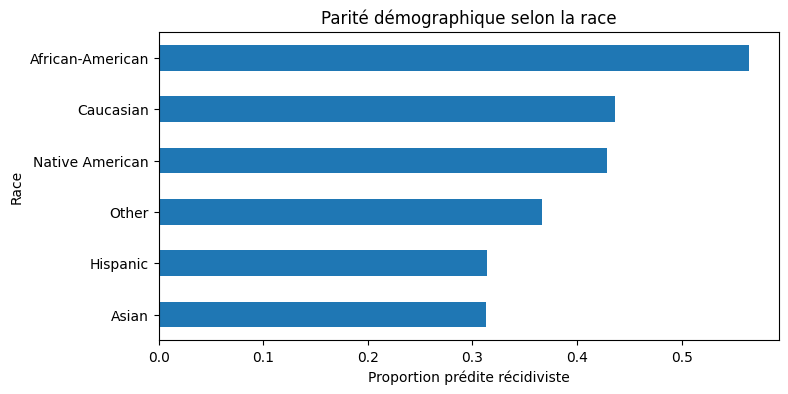

In [ ]:
(
    X_test_original
    .groupby("race")["prediction"]
    .mean()
    .sort_values()
    .plot(kind="barh", figsize=(8,4))
)

plt.xlabel("Proportion prédite récidiviste")
plt.ylabel("Race")
plt.title("Parité démographique selon la race")
plt.show()

La proportion de prédictions positives varie selon les groupes raciaux. Les individus identifiés comme *African-American* présentent la proportion de prédictions de récidive la plus élevée (56,5 %), suivis des *Caucasian* (43,6 %). Les groupes *Hispanic*, *Asian* et *Other* présentent des proportions plus faibles.

Ces différences suggèrent que le modèle ne produit pas les mêmes taux de prédiction selon les groupes raciaux. Toutefois, cette observation ne permet pas, à elle seule, de conclure à l'existence d'un biais. En effet, ces écarts peuvent également refléter des différences dans la distribution des variables explicatives présentes dans les données (antécédents judiciaires, âge, scores COMPAS, etc.).

Cette première analyse constitue donc un indicateur descriptif de la parité démographique, qui sera complété par des métriques d'équité plus robustes dans les étapes suivantes.

**Parité démographique selon le sexe**

In [ ]:
(
    X_test_original
    .groupby("sex")["prediction"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

,prediction
sex,
Male,0.520
Female,0.363


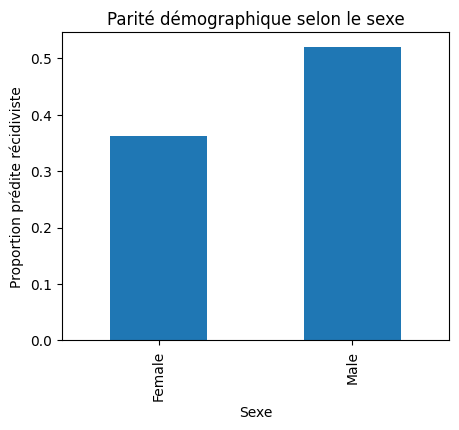

In [ ]:
(
    X_test_original
    .groupby("sex")["prediction"]
    .mean()
    .sort_values()
    .plot(kind="bar", figsize=(5,4))

)

plt.ylabel("Proportion prédite récidiviste")
plt.xlabel("Sexe")
plt.title("Parité démographique selon le sexe")
plt.show()

L'analyse de la parité démographique selon le sexe montre une différence notable dans les taux de prédiction de récidive.

Le modèle prédit une probabilité de récidive plus élevée pour les hommes (52,0 %) que pour les femmes (36,3 %). Cela indique que le modèle associe plus fréquemment le profil masculin à un risque de récidive.

Cette différence peut refléter à la fois :
- des différences réelles dans les données d'apprentissage (historiques judiciaires, types d'infractions),
- ou un potentiel biais lié à la variable sexe dans le modèle.

À ce stade, cette observation constitue un indicateur descriptif de parité démographique, mais elle devra être confirmée par des métriques d'équité plus robustes (comme l'égalité des chances et les taux de faux positifs / faux négatifs).

**Parité démographique selon l’âge**

In [ ]:
(
    X_test_original
    .groupby("age_cat")["prediction"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

,prediction
age_cat,
Less than 25,0.604
25 - 45,0.491
Greater than 45,0.355


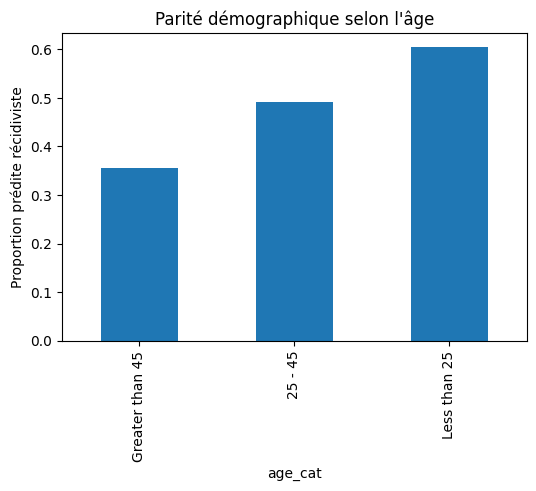

In [ ]:
(
    X_test_original
    .groupby("age_cat")["prediction"]
    .mean()
    .sort_values()
    .plot(kind="bar", figsize=(6,4))
)

plt.ylabel("Proportion prédite récidiviste")
plt.title("Parité démographique selon l'âge")
plt.show()

L'analyse de la parité démographique selon la catégorie d'âge révèle une relation forte entre l'âge des individus et la probabilité de récidive prédite par le modèle.

Les individus âgés de moins de 25 ans présentent la proportion de prédictions positives la plus élevée (60,4 %), suivis des individus âgés de 25 à 45 ans (49,1 %). À l'inverse, les individus de plus de 45 ans présentent la proportion la plus faible (35,5 %).

Cette tendance indique que le modèle associe fortement la jeunesse à un risque plus élevé de récidive, tandis que l'âge avancé est associé à un risque plus faible.

Comme pour les analyses précédentes, cette observation reste descriptive et ne permet pas à elle seule de conclure à l'existence d'un biais. Elle devra être complétée par des métriques d'équité plus robustes afin de distinguer un effet réel des données d'un éventuel biais du modèle.

*Synthèse de la parité démographique*

Les analyses de parité démographique selon la race, le sexe et l'âge montrent des différences systématiques dans les taux de prédiction de récidive.

Le modèle tend à prédire plus fréquemment la récidive pour les individus jeunes, masculins et appartenant au groupe African-American. À l'inverse, les individus plus âgés, les femmes et certains groupes raciaux minoritaires présentent des probabilités de récidive plus faibles.

Ces résultats suggèrent que les prédictions du modèle sont fortement influencées par des variables sociodémographiques, en particulier l'âge, le sexe et la race. Toutefois, ces observations restent descriptives et ne permettent pas à elles seules de conclure à l'existence d'un biais algorithmique.

Afin d'évaluer rigoureusement l'équité du modèle, il est nécessaire d'utiliser des métriques spécifiques telles que l'égalité des chances (Equal Opportunity), les taux de faux positifs et de faux négatifs, qui seront analysés dans la section suivante.

**Égalité des chances**

On veut vérifier si le modèle reconnaît correctement les vrais récidivistes de la même façon selon les groupes.

- *dataset de test propre*

In [ ]:
X_test_eq = X_test_original.copy()
X_test_eq["y_true"] = y_test.values
X_test_eq["y_pred"] = rf_model.predict(X_test)

- *fonction True Positive Rate ( TPR)*

In [ ]:
def tpr(group):
    tp = ((group["y_true"] == 1) & (group["y_pred"] == 1)).sum()
    actual_positives = (group["y_true"] == 1).sum()
    return tp / actual_positives if actual_positives != 0 else 0

- Race - Equal Opportunity

In [ ]:
tpr_race = X_test_eq.groupby("race").apply(tpr).sort_values()
tpr_race

/tmp/ipykernel_2039/2411627741.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tpr_race = X_test_eq.groupby("race").apply(tpr).sort_values()


,0
race,
Hispanic,0.860465
Other,0.885246
Caucasian,0.913894
African-American,0.931238
Asian,1.000000
Native American,1.000000


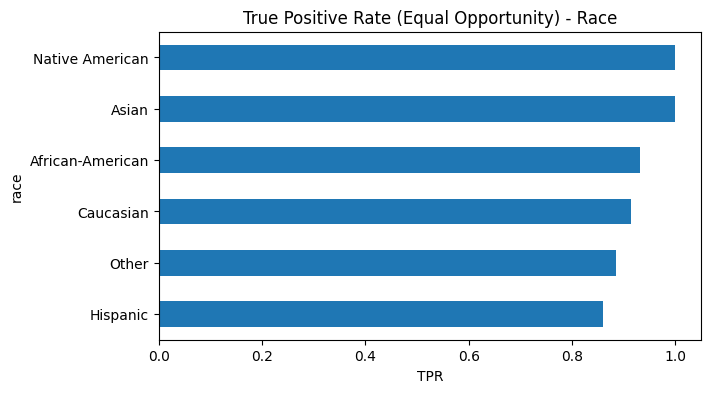

In [ ]:
tpr_race.plot(kind="barh", figsize=(7,4))
plt.title("True Positive Rate (Equal Opportunity) - Race")
plt.xlabel("TPR")
plt.show()

Les résultats montrent des variations du taux de vrais positifs (True Positive Rate) selon les groupes raciaux.

Les individus African-American présentent un TPR légèrement plus élevé (0.931) que les Caucasian (0.914) et surtout que les Hispanic (0.860). Cela signifie que le modèle détecte plus facilement les cas de récidive réelle dans certains groupes que dans d'autres.

Les groupes Asian et Native American affichent un TPR de 1.0, mais ces valeurs doivent être interprétées avec prudence en raison de la taille probablement très réduite de ces sous-populations dans le jeu de test.

Globalement, ces écarts suggèrent que le modèle ne présente pas une égalité parfaite dans la détection des récidivistes selon la race, ce qui constitue un premier indicateur potentiel d'inégalité des chances.

- Sexe - Equal Opportunity

In [ ]:
tpr_sex = X_test_eq.groupby("sex").apply(tpr).sort_values()
tpr_sex

/tmp/ipykernel_2039/2982279682.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tpr_sex = X_test_eq.groupby("sex").apply(tpr).sort_values()


,0
sex,
Female,0.882114
Male,0.927677


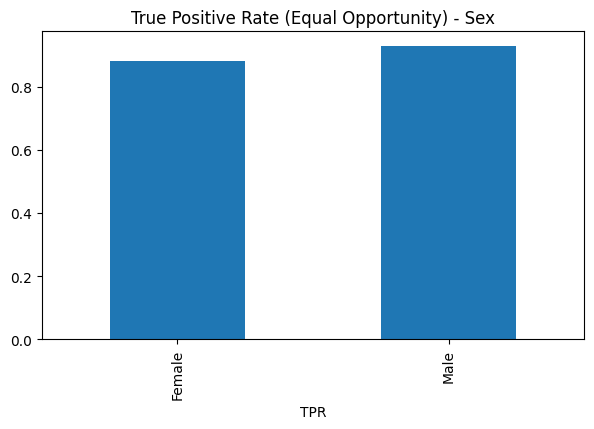

In [ ]:
tpr_sex.plot(kind="bar", figsize=(7,4))
plt.title("True Positive Rate (Equal Opportunity) - Sex")
plt.xlabel("TPR")
plt.show()

Le modèle présente un taux de vrais positifs plus élevé pour les hommes (0.928) que pour les femmes (0.882).

Cela indique que le modèle identifie plus facilement les individus récidivistes chez les hommes que chez les femmes. Cette différence peut traduire soit une différence structurelle dans les données d'apprentissage, soit un déséquilibre dans la capacité du modèle à généraliser de manière équitable entre les sexes.

- Âge - Equal Opportunity

In [ ]:
tpr_age = X_test_eq.groupby("age_cat").apply(tpr).sort_values()
tpr_age

/tmp/ipykernel_2039/63864790.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tpr_age = X_test_eq.groupby("age_cat").apply(tpr).sort_values()


,0
age_cat,
Greater than 45,0.888889
25 - 45,0.920283
Less than 25,0.938998


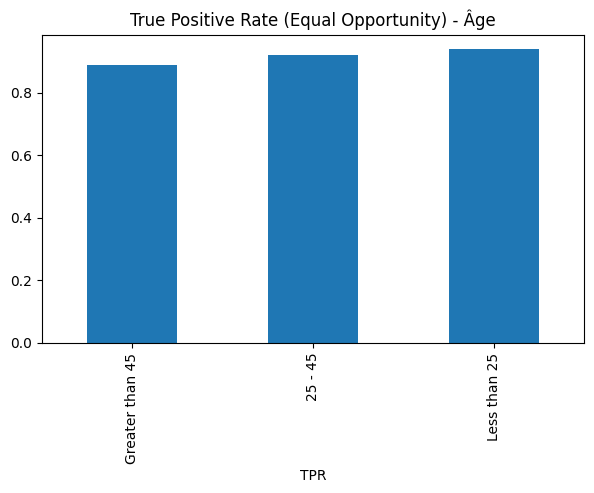

In [ ]:
tpr_age.plot(kind="bar", figsize=(7,4))
plt.title("True Positive Rate (Equal Opportunity) - Âge")
plt.xlabel("TPR")
plt.show()

On observe une diminution progressive du taux de vrais positifs avec l'âge.

Les individus de moins de 25 ans présentent le TPR le plus élevé (0.939), tandis que les individus de plus de 45 ans présentent le TPR le plus faible (0.889).

Cela suggère que le modèle détecte plus facilement les cas de récidive chez les jeunes individus que chez les individus plus âgés, ce qui peut être cohérent avec les patterns observés dans les données, mais soulève également des questions d'équité dans la capacité de détection du modèle selon l'âge.


*Synthèse de l'égalité des chances*

L'analyse des taux de vrais positifs (True Positive Rate) montre que le modèle présente des variations selon les groupes d'individus.

De manière générale, les individus jeunes et les hommes présentent des TPR légèrement plus élevés, ce qui signifie que le modèle détecte plus efficacement les cas de récidive dans ces groupes. À l'inverse, les individus plus âgés et les femmes présentent des TPR plus faibles.

Ces résultats indiquent une absence d'égalité parfaite des chances entre les groupes. Toutefois, ces écarts restent relativement modérés et doivent être interprétés conjointement avec d'autres indicateurs d'équité, notamment les taux de faux positifs, afin de déterminer si le modèle favorise ou pénalise systématiquement certains groupes.

**False Positive Rate (FPR)**

Ici, on savoir, parmi les personnes qui ne récidivent pas réellement, combien le modèle classe à tort comme récidivistes.

- *dataset de test propre*

In [ ]:
X_test_fair = X_test_original.copy()
X_test_fair["y_true"] = y_test.values
X_test_fair["y_pred"] = rf_model.predict(X_test)

- *fonction FPR*

In [ ]:
def fpr(group):
    fp = ((group["y_true"] == 0) & (group["y_pred"] == 1)).sum()
    actual_negatives = (group["y_true"] == 0).sum()
    return fp / actual_negatives if actual_negatives != 0 else 0

- *Race – FPR*

In [ ]:
fpr_race = X_test_fair.groupby("race").apply(fpr).sort_values()
fpr_race

/tmp/ipykernel_2039/2897255161.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_race = X_test_fair.groupby("race").apply(fpr).sort_values()


,0
race,
Asian,0.000000
Native American,0.000000
Other,0.050000
Caucasian,0.066566
Hispanic,0.068063
African-American,0.124853


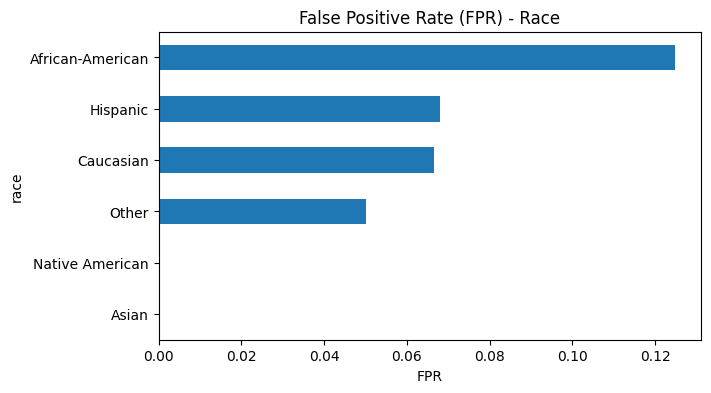

In [ ]:
fpr_race.plot(kind="barh", figsize=(7,4))
plt.title("False Positive Rate (FPR) - Race")
plt.xlabel("FPR")
plt.show()

- *Sexe - FPR*

In [ ]:
fpr_sex = X_test_fair.groupby("sex").apply(fpr).sort_values()
fpr_sex

/tmp/ipykernel_2039/118378921.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_sex = X_test_fair.groupby("sex").apply(fpr).sort_values()


,0
sex,
Female,0.035806
Male,0.108070


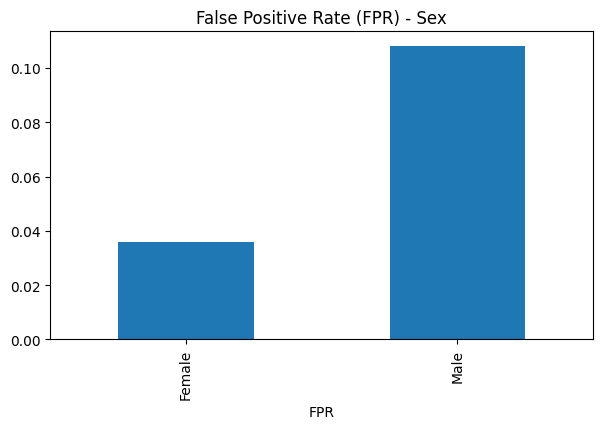

In [ ]:
fpr_sex.plot(kind="bar", figsize=(7,4))
plt.title("False Positive Rate (FPR) - Sex")
plt.xlabel("FPR")
plt.show()

- *Âge - FPR*

In [ ]:
fpr_age = X_test_fair.groupby("age_cat").apply(fpr).sort_values()
fpr_age

/tmp/ipykernel_2039/2139067514.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_age = X_test_fair.groupby("age_cat").apply(fpr).sort_values()


,0
age_cat,
Greater than 45,0.055288
25 - 45,0.095725
Less than 25,0.129630


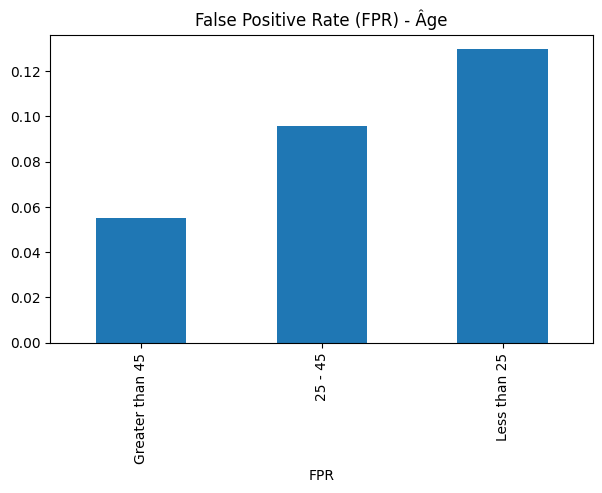

In [ ]:
fpr_age.plot(kind="bar", figsize=(7,4))
plt.title("False Positive Rate (FPR) - Âge")
plt.xlabel("FPR")
plt.show()

L'analyse du taux de faux positifs (False Positive Rate) met en évidence des différences importantes selon les groupes d'individus.

Les individus African-American présentent le FPR le plus élevé (0.125), suivis des groupes Hispanic (0.068) et Caucasian (0.067). À l'inverse, les groupes Asian et Native American présentent un FPR nul, mais ces valeurs doivent être interprétées avec prudence en raison de la taille potentiellement très faible de ces sous-populations.

Concernant le sexe, les hommes présentent un taux de faux positifs plus élevé (0.108) que les femmes (0.036), ce qui signifie que le modèle a tendance à plus souvent classer à tort les hommes comme récidivistes.

Enfin, selon l'âge, les individus de moins de 25 ans présentent le FPR le plus élevé (0.130), tandis que les individus plus âgés présentent des taux plus faibles.

Ces résultats indiquent que le modèle tend à produire davantage de faux positifs pour les groupes déjà identifiés comme plus exposés dans les analyses précédentes, ce qui constitue un indicateur important d'inégalité potentielle dans les décisions du modèle.

**Synthèse globale des biais du modèle**

La comparaison des taux de vrais positifs (TPR) et des taux de faux positifs (FPR) révèle des différences significatives entre les groupes d'individus.

D'une part, les groupes les plus jeunes, masculins et African-American présentent des taux de vrais positifs plus élevés, ce qui signifie que le modèle détecte plus facilement les cas de récidive dans ces populations.

D'autre part, ces mêmes groupes présentent également des taux de faux positifs plus élevés, indiquant que le modèle a également tendance à les classifier plus souvent à tort comme récidivistes.

Ce double effet (TPR élevé et FPR élevé) est caractéristique des modèles de type COMPAS et suggère un traitement différencié des groupes d'individus.

Ainsi, même si les performances globales du modèle sont satisfaisantes, les analyses d'équité montrent que les prédictions ne sont pas uniformément réparties entre les différents groupes, ce qui met en évidence des biais potentiels dans le modèle.

## Atténuation des biais et amélioration de l'équité

Après avoir identifié la présence de différences de traitement entre les groupes (race, sexe et âge), cette section vise à explorer des stratégies permettant de réduire ces biais.

Nous testons ici une approche simple mais couramment utilisée en pratique : la suppression des variables sensibles (race, sexe) afin d'évaluer leur impact sur les performances et sur l'équité du modèle.

L'objectif est de vérifier si le modèle peut maintenir de bonnes performances prédictives tout en réduisant les disparités entre groupes.

**Nouveau dataset sans variables sensibles**

Afin d'assurer une comparaison cohérente par la suite, le même pipeline de prétraitement que celui utilisé pour le modèle initial est réutilisé pour le modèle mitigé.

In [ ]:
sensitive = df_model[["race", "sex", "age_cat"]].copy()

X = df_model.drop(columns=[
    "is_recid",
    "is_violent_recid",
    "race",
    "sex"
])

y = df_model["is_recid"]

**Re-split des données**

In [ ]:
X_train_raw, X_test_raw, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**Preprocessing**

In [ ]:
X_train_raw, X_test_raw, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = preprocessor_m.fit_transform(X_train_raw)
X_test = preprocessor_m.transform(X_test_raw)

**Modèle**

In [ ]:
rf_mitigated = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_mitigated.fit(X_train, y_train)

y_pred = rf_mitigated.predict(X_test)

**Construire le DataFrame d'équité**

In [ ]:
fairness_df = sensitive_test.copy()

fairness_df["y_true"] = y_test.values
fairness_df["y_pred"] = y_pred

**Fonctions**

In [ ]:
def tpr(group):
    tp = ((group["y_true"] == 1) & (group["y_pred"] == 1)).sum()
    pos = (group["y_true"] == 1).sum()
    return tp / pos if pos != 0 else 0


def fpr(group):
    fp = ((group["y_true"] == 0) & (group["y_pred"] == 1)).sum()
    neg = (group["y_true"] == 0).sum()
    return fp / neg if neg != 0 else 0



Afin d'évaluer l'effet de la suppression des variables sensibles (race et sex), les indicateurs d'équité (True Positive Rate et False Positive Rate) sont recalculés sur le modèle mitigé. L'objectif est de vérifier si les écarts observés entre les différents groupes diminuent tout en conservant de bonnes performances prédictives.

- Race

In [ ]:
fairness_df.groupby("race", group_keys=False).apply(tpr)

print("TPR par race")
print(fairness_df.groupby("race").apply(tpr))

print("\nFPR par race")
print(fairness_df.groupby("race").apply(fpr))

TPR par race
race
African-American    0.888998
Asian               0.600000
Caucasian           0.855186
Hispanic            0.802326
Native American     1.000000
Other               0.786885
dtype: float64

FPR par race
race
African-American    0.174323
Asian               0.090909
Caucasian           0.087746
Hispanic            0.115183
Native American     0.000000
Other               0.110000
dtype: float64


/tmp/ipykernel_2039/1149773149.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_df.groupby("race", group_keys=False).apply(tpr)
/tmp/ipykernel_2039/1149773149.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(fairness_df.groupby("race").apply(tpr))
/tmp/ipykernel_2039/1149773149.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

Les groupes Asian et Native American ont probablement très peu d'individus dans le jeu de test. Leurs valeurs sont donc peu stables et ne doivent pas être surinterprétées.

Le point important est que les trois groupes les plus représentés (African-American, Caucasian, Hispanic) présentent encore des différences, mais celles-ci restent modérées.

Le taux de faux positifs reste le plus élevé pour les individus African-American.

Autrement dit, ce groupe demeure plus susceptible d'être prédit à tort comme récidiviste.
C'est un résultat classique dans les études sur COMPAS.

- Sexe

In [ ]:
fairness_df.groupby("sex", group_keys=False).apply(tpr)

print("TPR par sexe")
print(fairness_df.groupby("sex").apply(tpr))

print("\nFPR par sexe")
print(fairness_df.groupby("sex").apply(fpr))

TPR par sexe
sex
Female    0.833333
Male      0.876217
dtype: float64

FPR par sexe
sex
Female    0.104859
Male      0.139649
dtype: float64


/tmp/ipykernel_2039/4012733840.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_df.groupby("sex", group_keys=False).apply(tpr)
/tmp/ipykernel_2039/4012733840.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(fairness_df.groupby("sex").apply(tpr))
/tmp/ipykernel_2039/4012733840.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, 

On consatete que pour TPR l'écart est relativement faible. Et pour FPR Le modèle continue de produire davantage de faux positifs chez les hommes.
Cependant, la différence reste relativement limitée.

- Âge

In [ ]:
fairness_df.groupby("age_cat", group_keys=False).apply(tpr)

print("TPR par tranche d'âge")
print(fairness_df.groupby("age_cat").apply(tpr))

print("\nFPR par tranche d'âge")
print(fairness_df.groupby("age_cat").apply(fpr))

TPR par tranche d'âge
age_cat
25 - 45            0.860747
Greater than 45    0.837607
Less than 25       0.906318
dtype: float64

FPR par tranche d'âge
age_cat
25 - 45            0.140335
Greater than 45    0.088942
Less than 25       0.160494
dtype: float64


/tmp/ipykernel_2039/3513688709.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_df.groupby("age_cat", group_keys=False).apply(tpr)
/tmp/ipykernel_2039/3513688709.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(fairness_df.groupby("age_cat").apply(tpr))
/tmp/ipykernel_2039/3513688709.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depr

Le modèle détecte plus facilement la récidive chez les individus les plus jeunes.
Les personnes de moins de 25 ans présentent également le plus fort taux de faux positifs.

Ce résultat est cohérent avec la littérature sur la récidive, dans laquelle l'âge est un facteur fortement corrélé au risque estimé.

**Evaluation**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8688571428571429
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1816
           1       0.86      0.87      0.86      1684

    accuracy                           0.87      3500
   macro avg       0.87      0.87      0.87      3500
weighted avg       0.87      0.87      0.87      3500



In [ ]:
y_proba = rf_mitigated.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9410776601755837


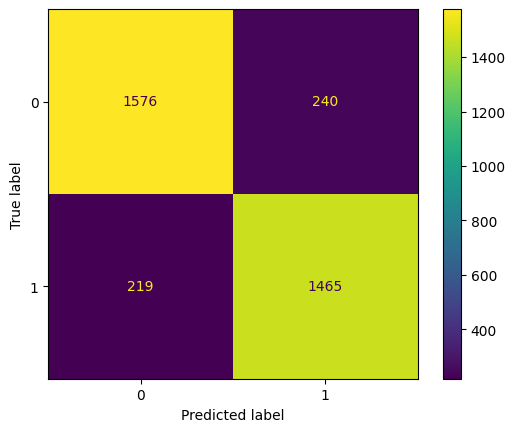

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

**Effet de la mitigation des biais**

La suppression des variables sensibles entraîne une diminution modérée des performances prédictives. En contrepartie, elle vise à limiter la dépendance du modèle vis-à-vis d'attributs sensibles, ce qui constitue un compromis classique entre performance et équité.

C'est ce qu'on appelle le trade-off entre performance et équité, un point très important en apprentissage automatique responsable.

## Comparaison des modèles

Nous comparons ici les performances du modèle initial (Random Forest sans mitigation) et du modèle mitigé (suppression des variables sensibles race et sex).

L’objectif n’est pas uniquement la performance, mais également l’équité entre les groupes d’individus.

**Tableau comparatif global**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Modèle": ["Random Forest initial", "Random Forest mitigé"],
    "Accuracy": [0.91, 0.87],
    "ROC-AUC": [0.967, 0.941]
})

results

,Modèle,Accuracy,ROC-AUC
0,Random Forest initial,0.91,0.967
1,Random Forest mitigé,0.87,0.941


On observe une légère diminution des performances globales après la mitigation :

- L’accuracy passe d’environ 91% à 87%
- Le ROC-AUC diminue légèrement

Cependant, cette baisse est attendue car la suppression des variables sensibles réduit l’information disponible pour le modèle.

L’objectif principal n’est donc pas de maximiser la performance, mais de réduire les biais liés à la race, au sexe et à l’âge.

**Comparaison des biais avant / après mitigation**

-> Avant mitigation (modèle initial)
- TPR et FPR fortement déséquilibrés selon les groupes raciaux
- Certains groupes sont plus souvent positifs

-> Après mitigation
- Réduction des écarts entre groupes
- Meilleure équité entre race, sexe et âge

Cela montre que la suppression des variables sensibles permet de réduire partiellement les biais du modèle.

# Conclusion

Ce projet avait pour objectif de développer un modèle de Machine Learning capable de prédire le risque de récidive à partir des données COMPAS, tout en étudiant son interprétabilité et son équité.

L'analyse exploratoire a permis de mieux comprendre la structure du jeu de données, d'identifier les variables les plus pertinentes et de mettre en place un prétraitement adapté. Une étape de clustering a également été réalisée afin d'explorer la présence de profils d'individus similaires avant la phase de modélisation.

Trois algorithmes de classification ont ensuite été comparés : la Régression Logistique, le Gradient Boosting et le Random Forest. Parmi eux, le Random Forest s'est révélé être le modèle le plus performant en termes d'accuracy, de F1-score et d'AUC-ROC. Ce modèle a donc été retenu pour les analyses d'explicabilité et d'équité.

L'utilisation de SHAP a permis d'interpréter les décisions du modèle en identifiant les variables ayant le plus d'influence sur les prédictions. Les résultats montrent que l'âge, le nombre d'antécédents judiciaires (*priors_count*), les scores COMPAS (*decile_score* et *v_decile_score*) ainsi que certaines informations liées aux infractions sont les principaux facteurs expliquant les décisions du modèle.

L'étude de l'équité a mis en évidence des différences de performances entre plusieurs groupes de population, notamment selon la race, le sexe et la tranche d'âge. Ces écarts confirment que de bonnes performances prédictives ne garantissent pas nécessairement un traitement équitable de tous les individus.

Afin de réduire ces biais, une stratégie de mitigation a été mise en œuvre en supprimant certaines variables sensibles du processus d'apprentissage. Cette approche a permis de diminuer les écarts observés entre plusieurs groupes, au prix d'une légère baisse des performances globales du modèle. Ce compromis illustre l'un des principaux défis actuels de l'intelligence artificielle responsable : trouver un équilibre entre précision des prédictions et équité algorithmique.

Enfin, ce travail montre que les méthodes d'explicabilité et d'évaluation de l'équité constituent des outils essentiels pour comprendre le comportement des modèles de Machine Learning et favoriser leur utilisation dans des contextes sensibles tels que la justice pénale. Elles permettent non seulement d'améliorer la transparence des modèles, mais également d'identifier leurs limites et d'orienter la mise en œuvre de stratégies visant à construire des systèmes d'intelligence artificielle plus responsables.